# Robustness Analysis: Adjoint and Toggle-Frame Objectives Subject to Either Multiplicative or Additive Errors

This notebook compares the performance of the adjoint and toggling-frame robustness objectives for multiplicative and additive error terms in the system's Hamiltonian. 

## Imports

In [1]:
import Pkg; Pkg.activate(@__DIR__); Pkg.instantiate();
Pkg.develop(path="../../QuantumCollocation.jl")
using PiccoloQuantumObjects
using QuantumCollocation
using ForwardDiff
using LinearAlgebra
using SparseArrays
using Statistics
using CairoMakie
using Random
using NamedTrajectories

  Activating project at `~/Documents/GitHub/robust_control_sam/src`
┌ Warning: Circular dependency detected.
│ Precompilation will be skipped for dependencies in this cycle:
│  ┌ Piccolissimo
│  └─ QuantumCollocation
└ @ Base.Precompilation precompilation.jl:651
   Resolving package versions...
  No Changes to `~/Documents/GitHub/robust_control_sam/src/Project.toml`
  No Changes to `~/Documents/GitHub/robust_control_sam/src/Manifest.toml`
┌ Warning: Circular dependency detected.
│ Precompilation will be skipped for dependencies in this cycle:
│  ┌ Piccolissimo
│  └─ QuantumCollocation
└ @ Base.Precompilation precompilation.jl:651
┌ Warning: Replacing docs for `QuantumCollocation.ProblemTemplates.UnitaryUniversalProblem :: Union{}` in module `QuantumCollocation.ProblemTemplates`
└ @ Base.Docs docs/Docs.jl:243
ERROR: Method overwriting is not permitted during Module precompilation. Use `__precompile__(false)` to opt-out of precompilation.
┌ Warning: Replacing docs for `QuantumCollocation

In [108]:
# Problem parameters
T = 50
Δt = 2.0 # make 4?
U_goal = GATES.X
H_drive = [PAULIS.X, PAULIS.Y]
piccolo_opts = PiccoloOptions(verbose=false)
pretty_print(X::AbstractMatrix) = Base.show(stdout, "text/plain", X);
sys = QuantumSystem(H_drive)
seed = 2
F=0.9999
num_iter = 2000
hess = false
hess_iter = 100
dda = 2.0
a_bound = 1.0
Q=100.0

100.0

In [109]:
# Default
Random.seed!(1)
def = UnitarySmoothPulseProblem(sys, U_goal, T, Δt; Δt_max=Δt, Δt_min=Δt, a_bound=a_bound, dda_bound=dda, Q_t=1.0)
push!(def.constraints, FinalUnitaryFidelityConstraint(U_goal, :Ũ⃗, F, def.trajectory))
solve!(def, max_iter=num_iter, print_level=1, options=IpoptOptions(eval_hessian=false))
if hess
    solve!(def, max_iter=hess_iter, print_level=1)
end

In [110]:
gen = [GATES.X, GATES.Y]
unitary_rollout_fidelity(def.trajectory, QuantumSystem(0.0 * GATES.Z, gen))

0.9999999996095492

In [111]:
# Toggling by Bikrant
Random.seed!(seed)
∂ₑHₐ = [PAULIS.Z]
varsys_bik = VariationalQuantumSystem(
    H_drive,
    ∂ₑHₐ
)
Random.seed!(seed)
add_prob = UnitaryToggleProblem(
            varsys_bik, U_goal, T, Δt;
            a_bound=a_bound,
            dda_bound=dda,
            Δt_min=Δt,
            Δt_max=Δt,
            piccolo_options=piccolo_opts,
            Q=0.0,
            Q_t=Q
        )
push!(add_prob.constraints, FinalUnitaryFidelityConstraint(U_goal, :Ũ⃗, F, add_prob.trajectory))
solve!(add_prob, max_iter=num_iter, print_level=5, options=IpoptOptions(eval_hessian=false))#, output_file="tog_log_hessians.txt"))
if hess
    solve!(add_prob, max_iter=hess_iter, print_level=5)
end

In [112]:
# Adjoint, rollout initialization
Random.seed!(seed)
∂ₑHₐ = PAULIS.X
varsys_add = VariationalQuantumSystem(
    H_drive,
    [PAULIS.Z]
)

var_count = length(varsys_add.G_vars)

varadd_prob = UnitaryVariationalProblem(
    varsys_add, U_goal, T, Δt;
    robust_times = [[T] for _ in 1:var_count],
    Δt_min=Δt,
    Δt_max=Δt, 
    a_bound=a_bound, 
    dda_bound=dda,
    Q=0.0,
    Q_r = Q,   # > 0
    Q_s = 0.0,     # (irrelevant since sensitive_times is empty)
    piccolo_options = PiccoloOptions(verbose=false)
)

init_traj = deepcopy(varadd_prob.trajectory)
init_traj.Ũ⃗ .= unitary_rollout(init_traj, varsys_add)

varadd_prob = UnitaryVariationalProblem(
    varsys_add, U_goal, T, Δt;
    robust_times = [[T] for _ in 1:var_count],
    Δt_min=Δt,
    Δt_max=Δt, 
    init_trajectory = remove_components(init_traj, [:Ũ⃗ᵥ1]),
    a_bound=a_bound, 
    dda_bound=dda,
    Q=0.0,
    Q_r = Q,   # > 0
    Q_s = 0.0,     # (irrelevant since sensitive_times is empty)
    piccolo_options = PiccoloOptions(verbose=false)
)
push!(varadd_prob.constraints, FinalUnitaryFidelityConstraint(U_goal, :Ũ⃗, F, varadd_prob.trajectory))
solve!(varadd_prob, max_iter=num_iter, print_level=5, options=IpoptOptions(eval_hessian=false))
if hess
    solve!(varadd_prob, max_iter=hess_iter, print_level=5)
end
#solve!(varadd_prob, max_iter=100, print_level=5, options=IpoptOptions(eval_hessian=true))#, output_file="varadd_log_two.txt"))
#solve!(varadd_prob, max_iter=num_iter, print_level=5, options=IpoptOptions(output_file="varadd_log_two.txt"))
#solve!(varadd_prob, max_iter=50, print_level=5)

In [113]:
∂ₑH = [PAULIS.X, PAULIS.Y, PAULIS.Z]
H_drive = [PAULIS.X, PAULIS.Y]
error_op = PAULIS.Z
function var_obj(prob::DirectTrajOptProblem, H_drive::Vector{Matrix{ComplexF64}}, error_op::Matrix{ComplexF64})
    Δt = prob.trajectory.Δt[1]
    varsys = VariationalQuantumSystem(
        H_drive,
        [error_op]
    )
    ww = iso_vec_to_operator(variational_unitary_rollout(prob.trajectory, varsys)[2][1][:,end])
    d = size(ww)[1]
    return norm(tr(ww'ww)) / (T * Δt)^2 / d
end

var_obj (generic function with 2 methods)

In [114]:
var_obj(varadd_prob, H_drive, error_op)

2.9033400917599965e-9

In [115]:
var_obj(add_prob, H_drive, error_op)

0.00030057602957329546

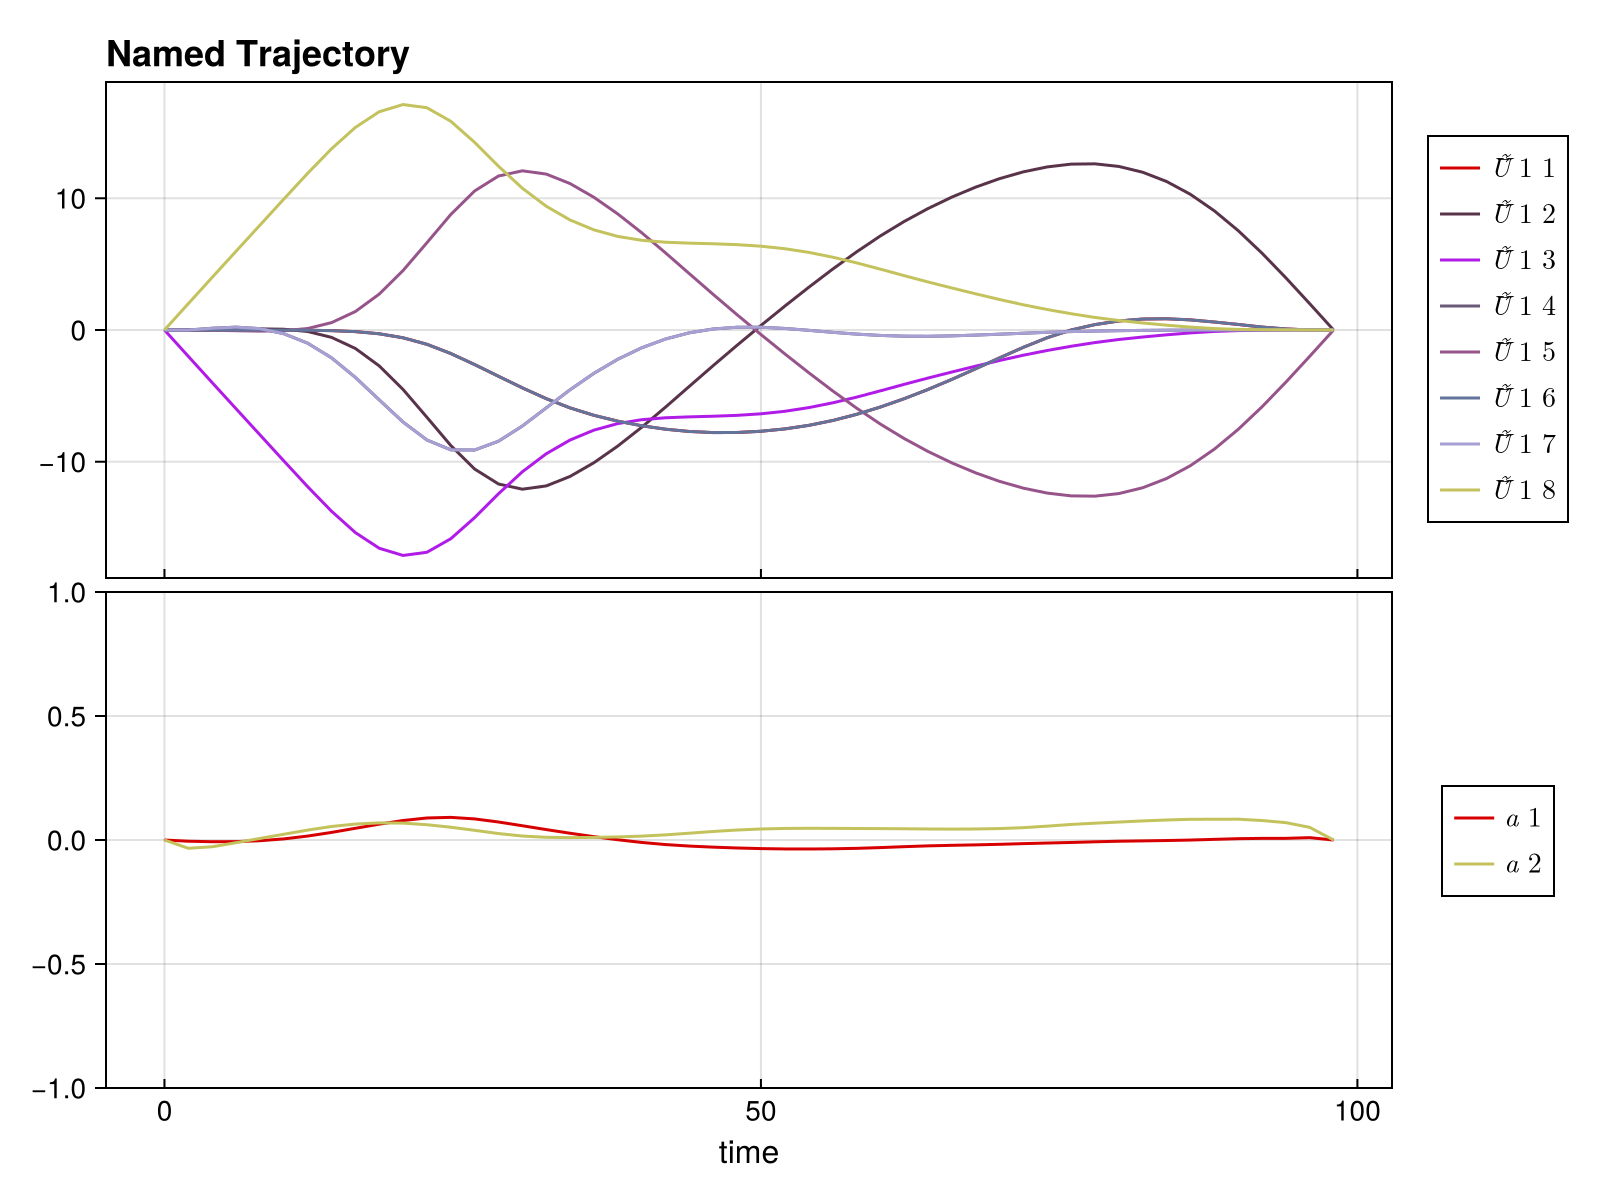

In [116]:
var_traj = varadd_prob.trajectory
CairoMakie.plot(var_traj, [:Ũ⃗ᵥ1, :a])

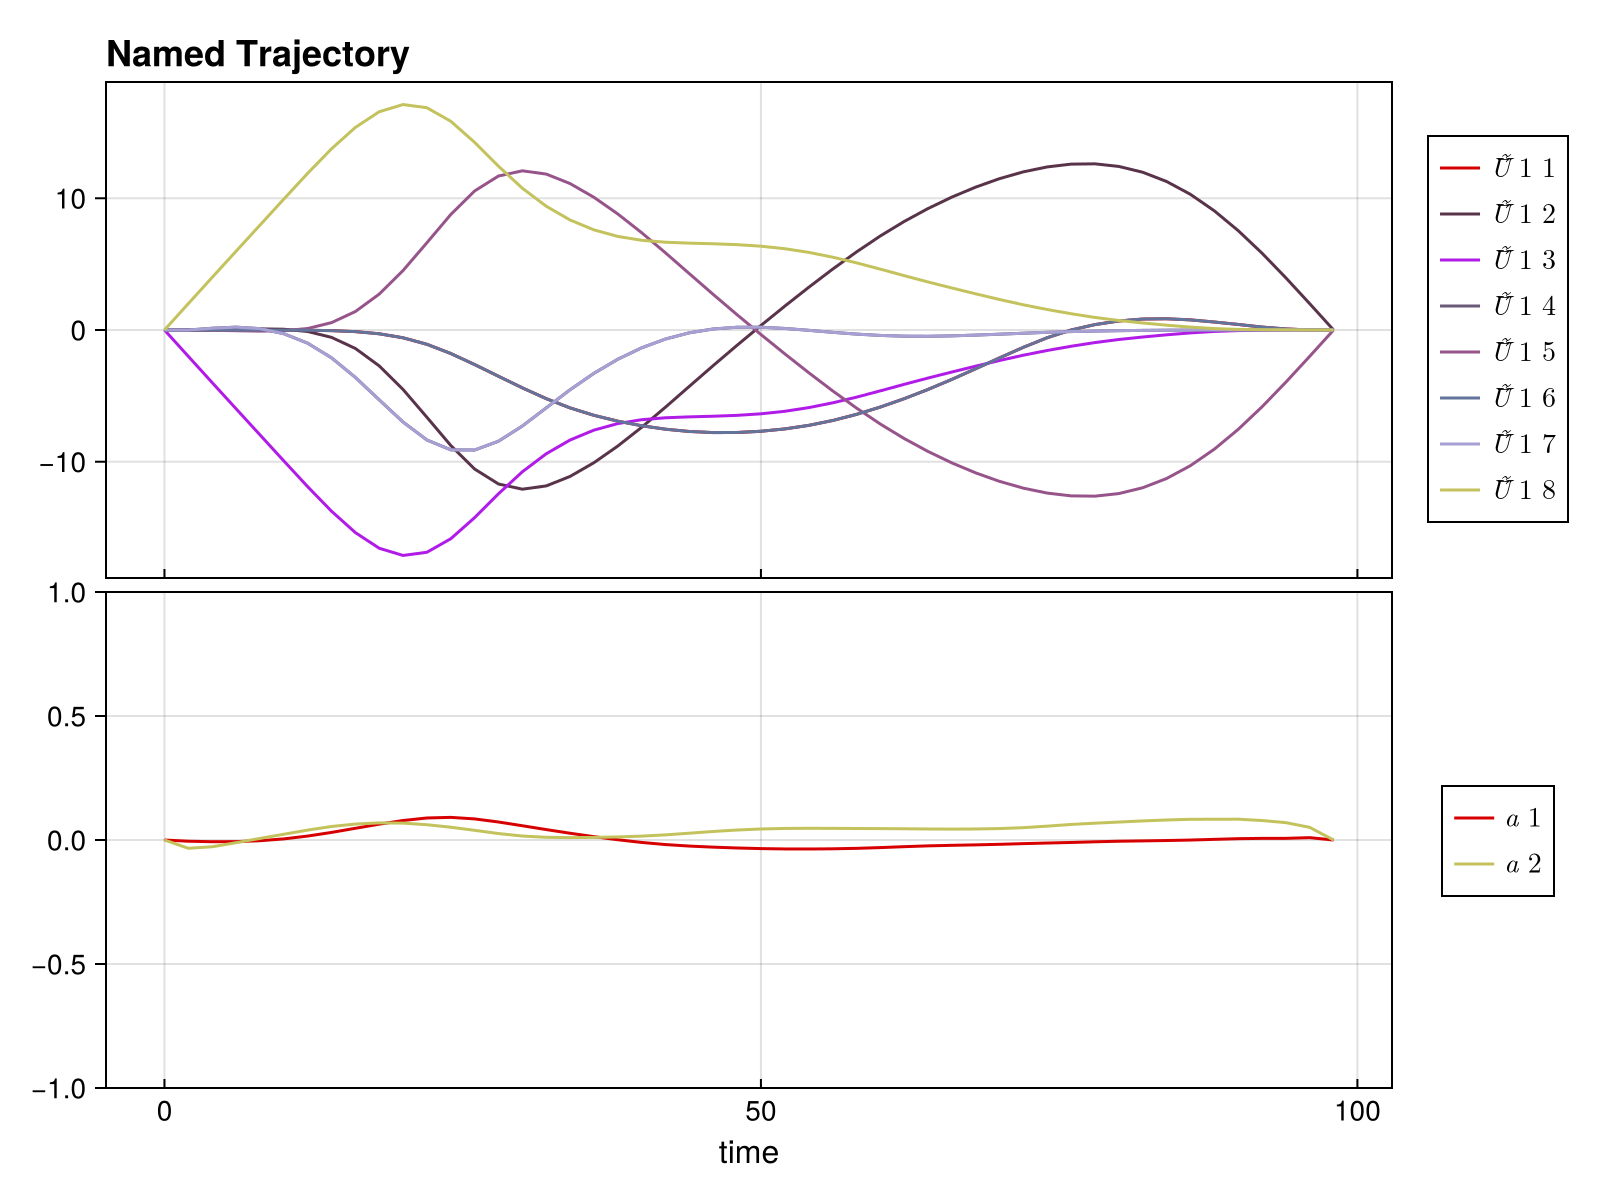

In [117]:
CairoMakie.plot(var_traj, [:Ũ⃗ᵥ1, :a])

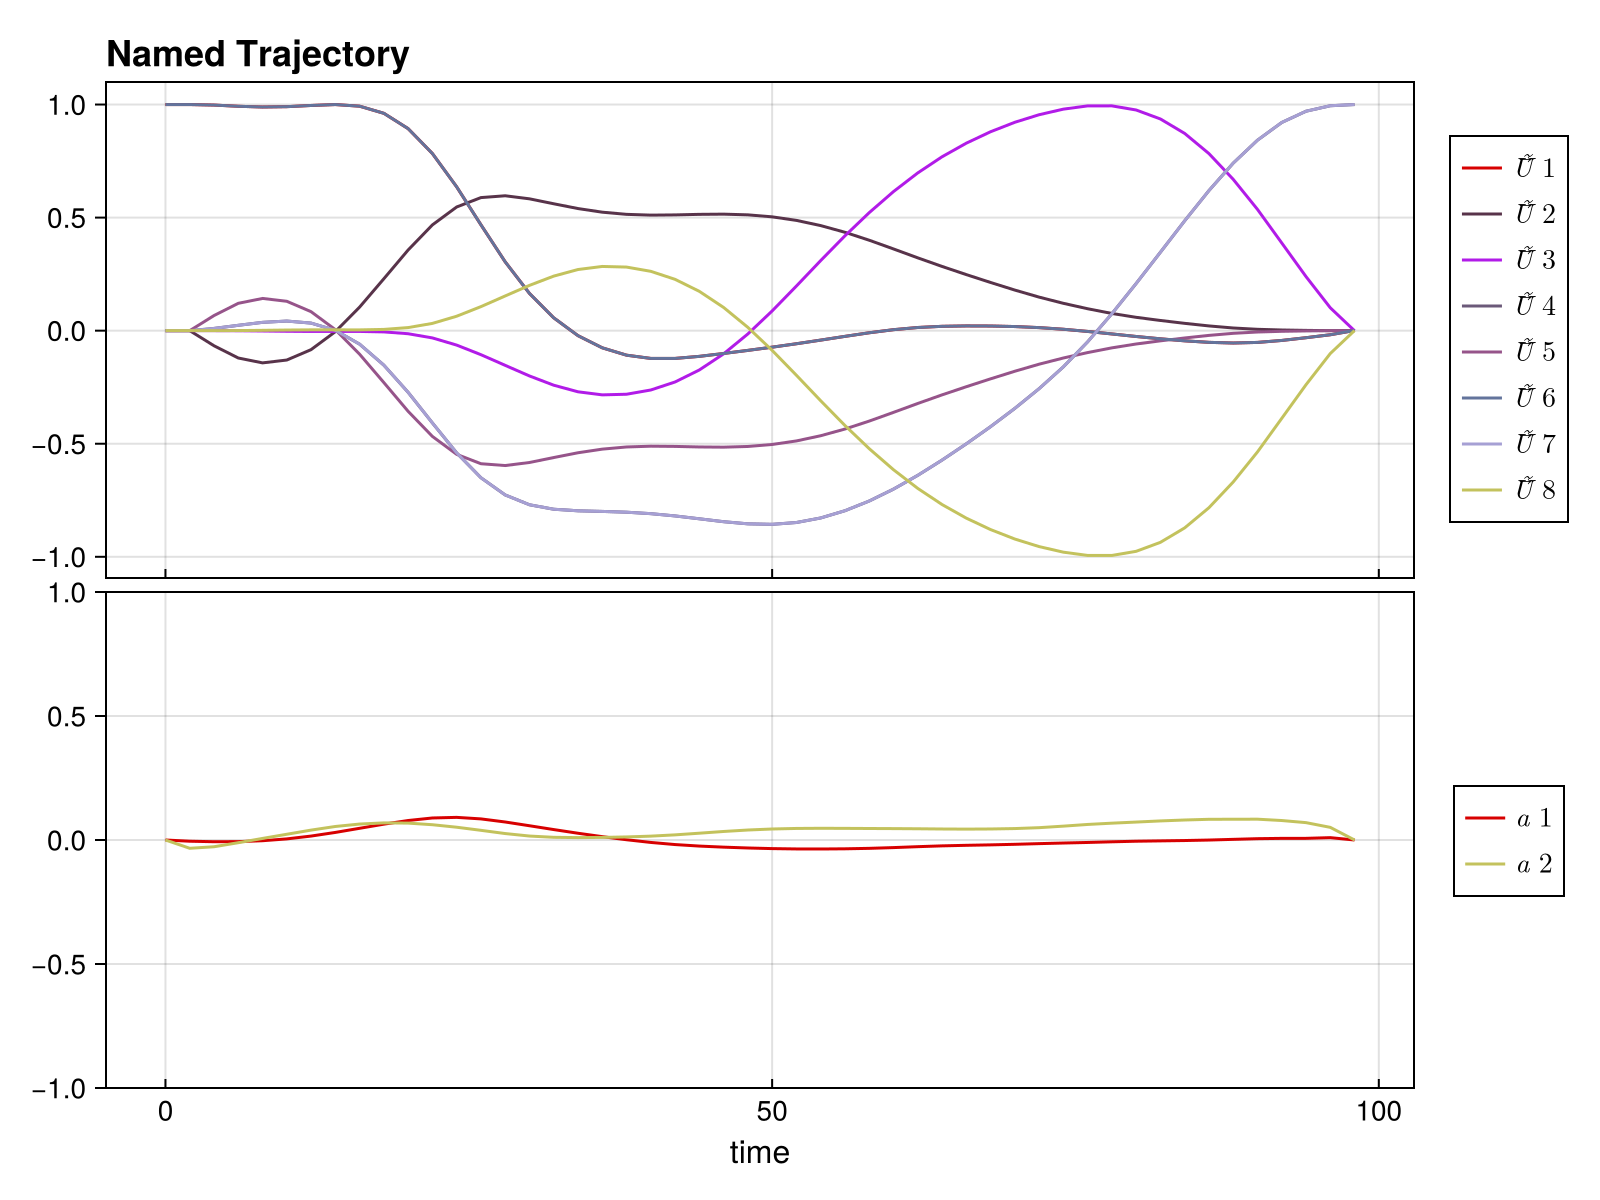

In [118]:
CairoMakie.plot(var_traj, [:Ũ⃗, :a])

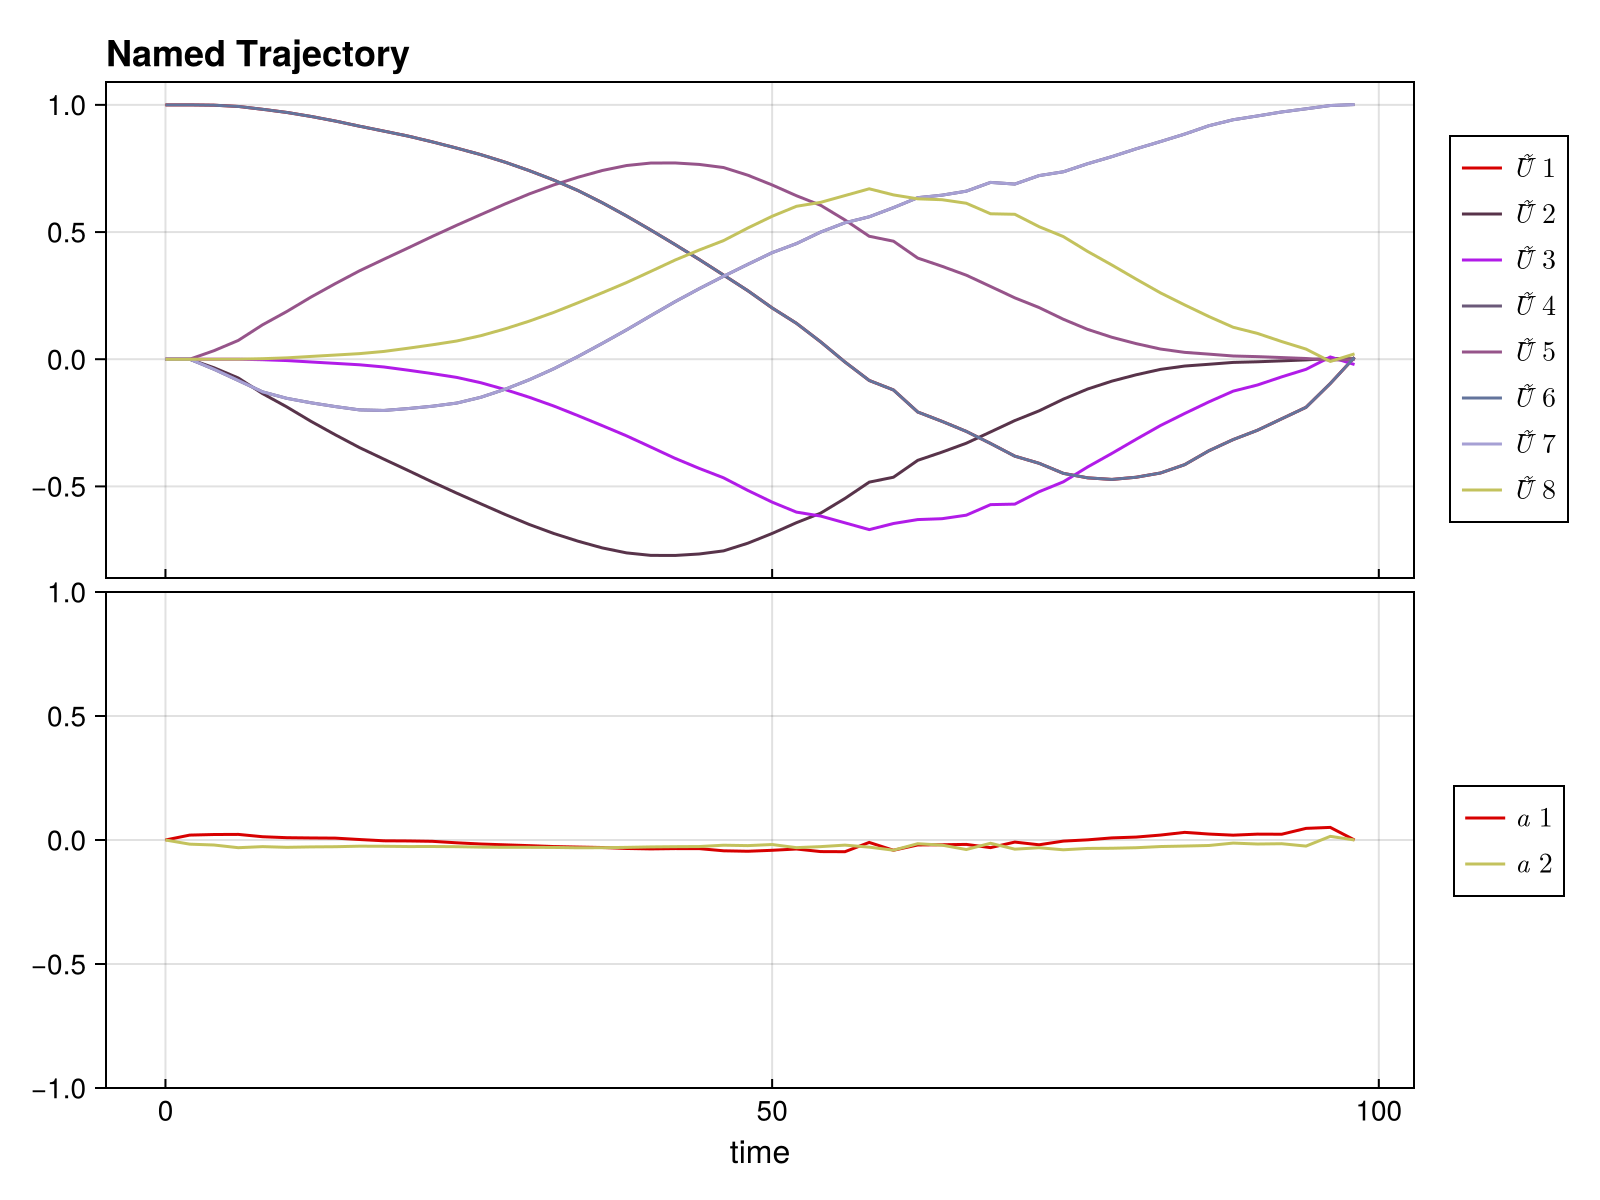

In [119]:
CairoMakie.plot(add_prob.trajectory, [:Ũ⃗, :a])

In [120]:
init_traj.names

(:Ũ⃗, :a, :da, :dda, :Δt, :Ũ⃗ᵥ1)

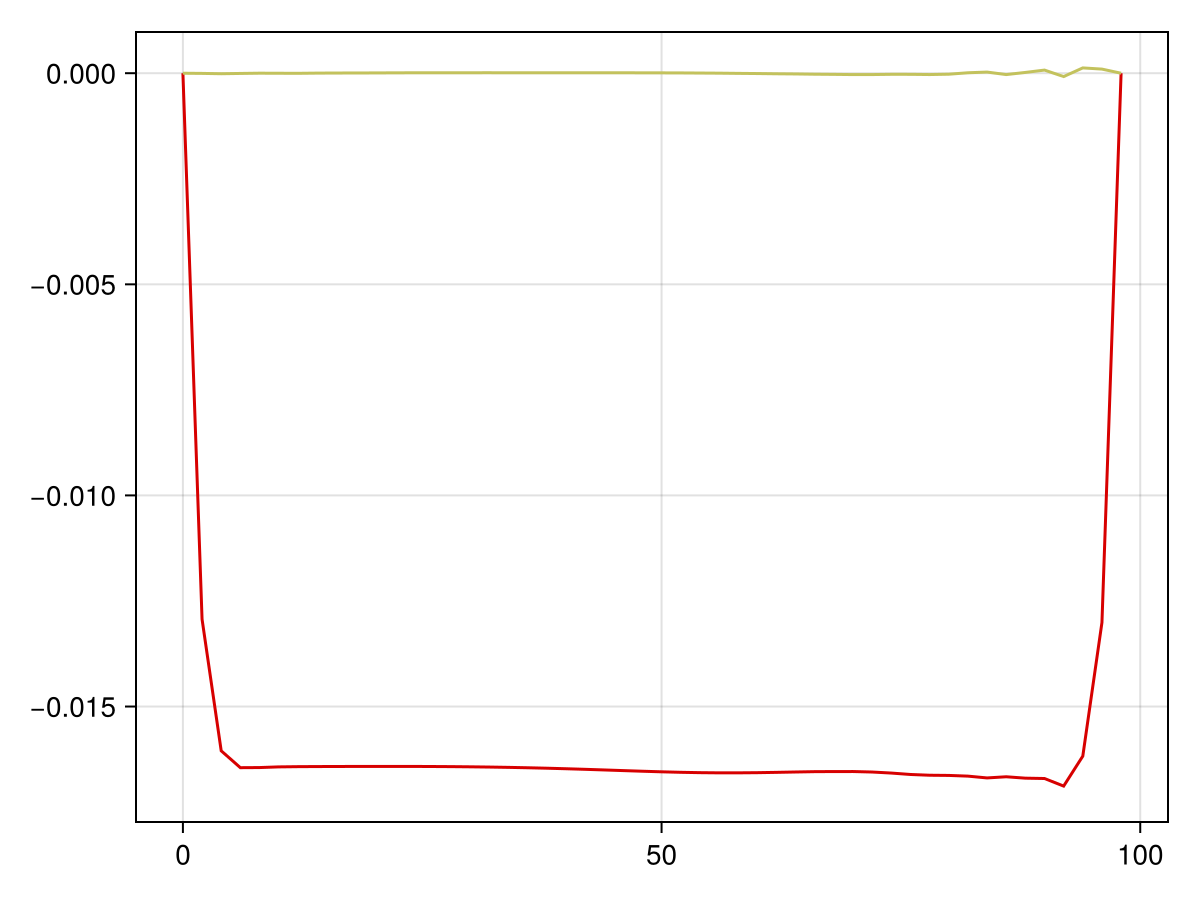

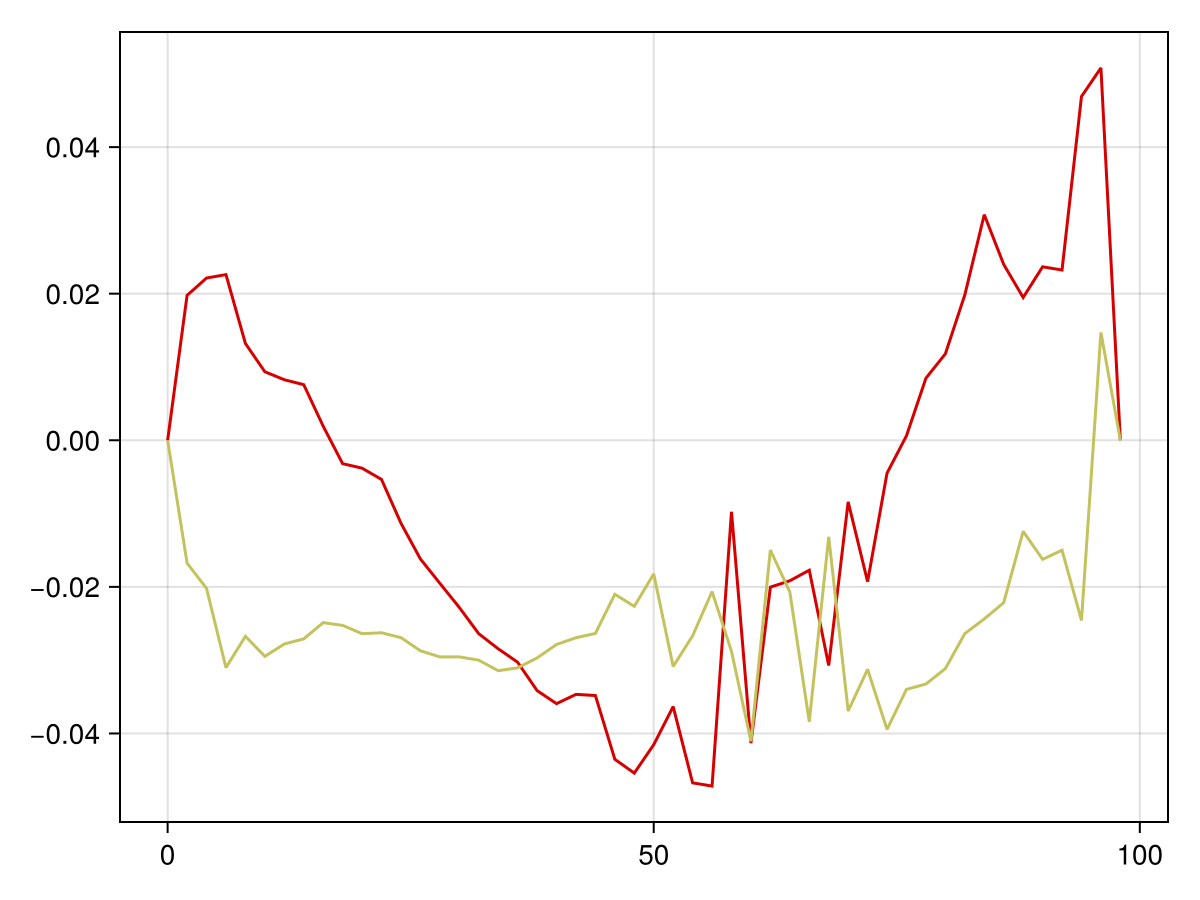

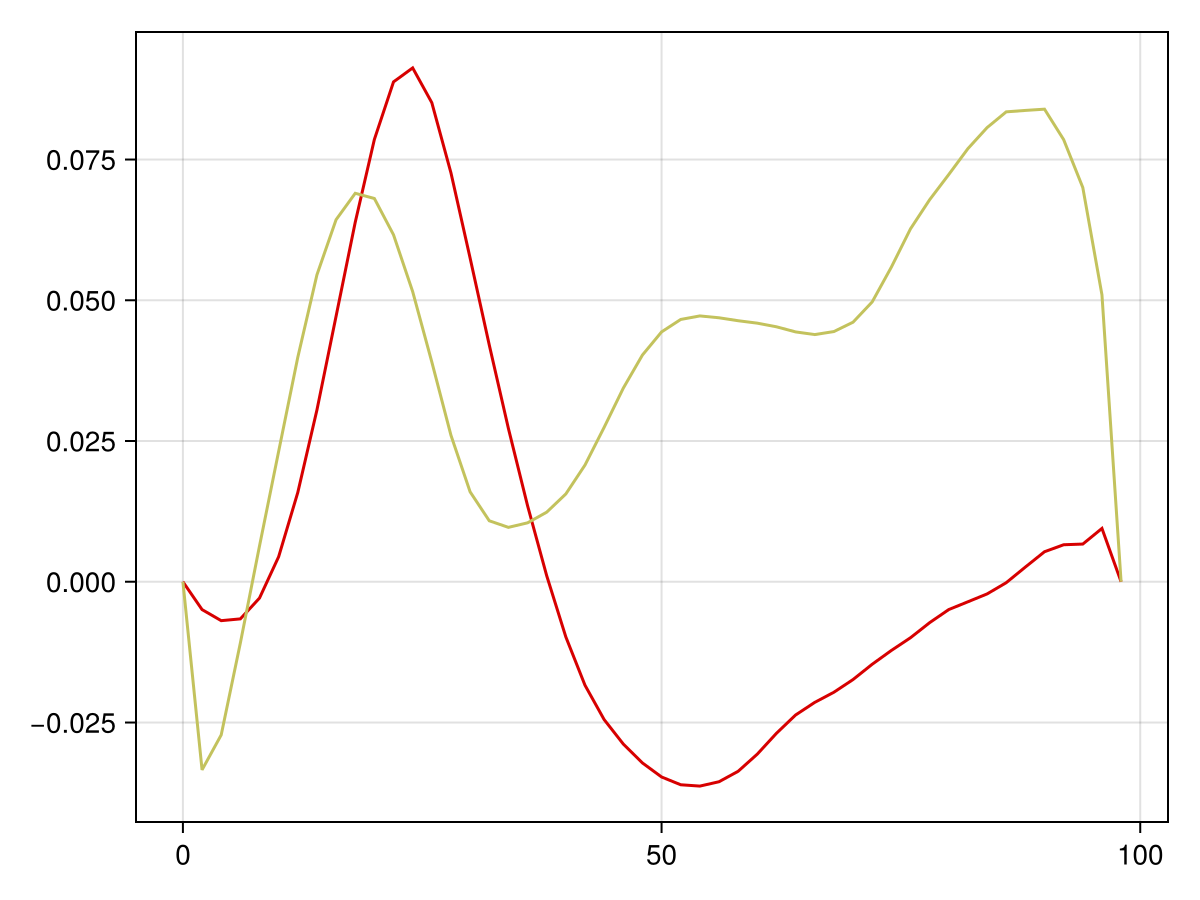

CairoMakie.Screen{IMAGE}


In [121]:
display(CairoMakie.plot(def.trajectory, :a))
display(CairoMakie.plot(add_prob.trajectory, :a))
display(CairoMakie.plot(varadd_prob.trajectory, :a))

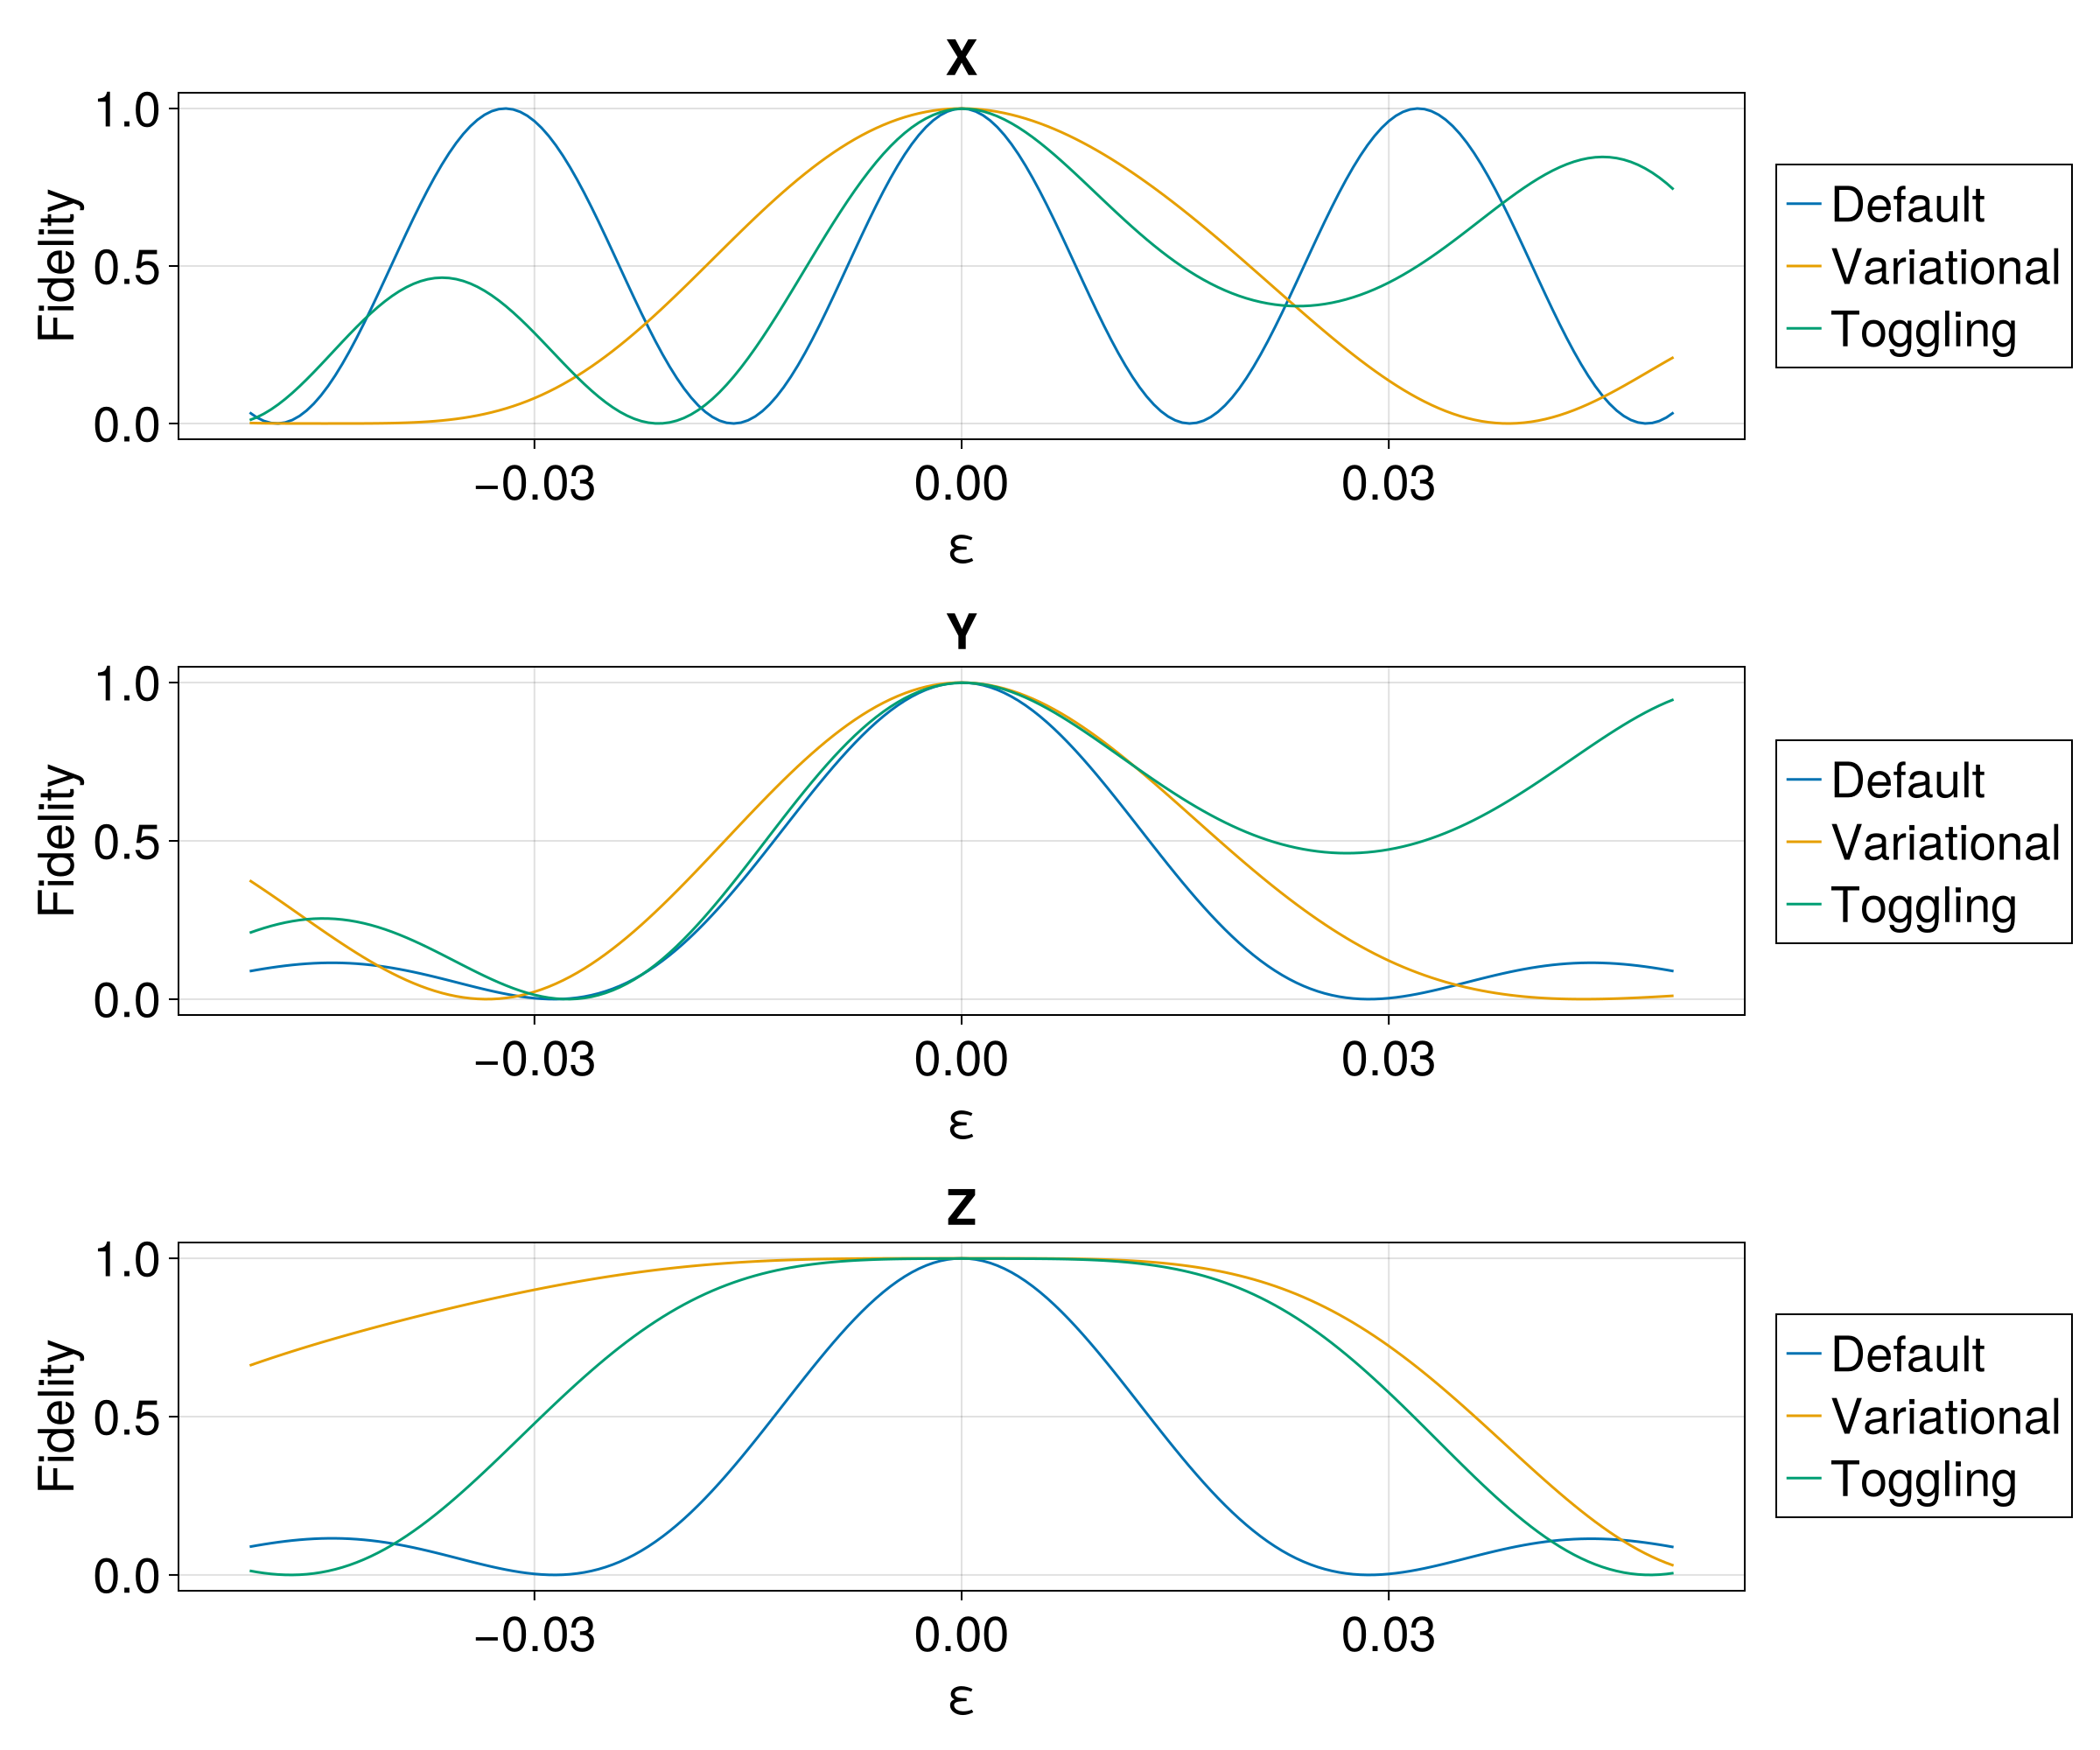

CairoMakie.Screen{IMAGE}


In [122]:
H_drive_add = H_drive  # (kept from your snippet, though it's unused below)

f = Figure(fontsize = 28, size = (1200, 1000))
axX = Axis(f[1, 1], title = "X", xlabel = "ε", ylabel = "Fidelity")#, yscale = log10)
axY = Axis(f[2, 1], title = "Y", xlabel = "ε", ylabel = "Fidelity")#, yscale = log10)
axZ = Axis(f[3, 1], title = "Z", xlabel = "ε", ylabel = "Fidelity")#, yscale = log10)

colors = Makie.wong_colors()
εs = -0.05:0.0005:.05

gen = [PAULIS.X, PAULIS.Y]

axes_paulis = [
    (axX, PAULIS.X),
    (axY, PAULIS.Y),
    (axZ, PAULIS.Z),
]

problems = [
    (def,        "Default"),
    (varadd_prob, "Variational"),
    (add_prob, "Toggling"),
    #(f_uni_prob,   "Universal"),
    # (f_uni_prob, "fast universal"),
    # (rf_uni_prob,"really fast universal"),
]

# Helper to compute the curve once per (problem, Pauli)
fidelity_curve(prob, pauli) = [unitary_rollout_fidelity(prob.trajectory, QuantumSystem(ε * pauli, gen)) for ε in εs]

# Plot everything with two compact loops
for (ax, pauli) in axes_paulis
    for (i, (prob, label)) in enumerate(problems)
        ys = norm.(fidelity_curve(prob, pauli))
        lines!(ax, εs, ys; label = label, color = colors[i], linestyle = :solid)
    end
end

Legend(f[1, 2], axX, position = :lb)
Legend(f[2, 2], axY, position = :lb)
Legend(f[3, 2], axZ, position = :lb)

display(f)



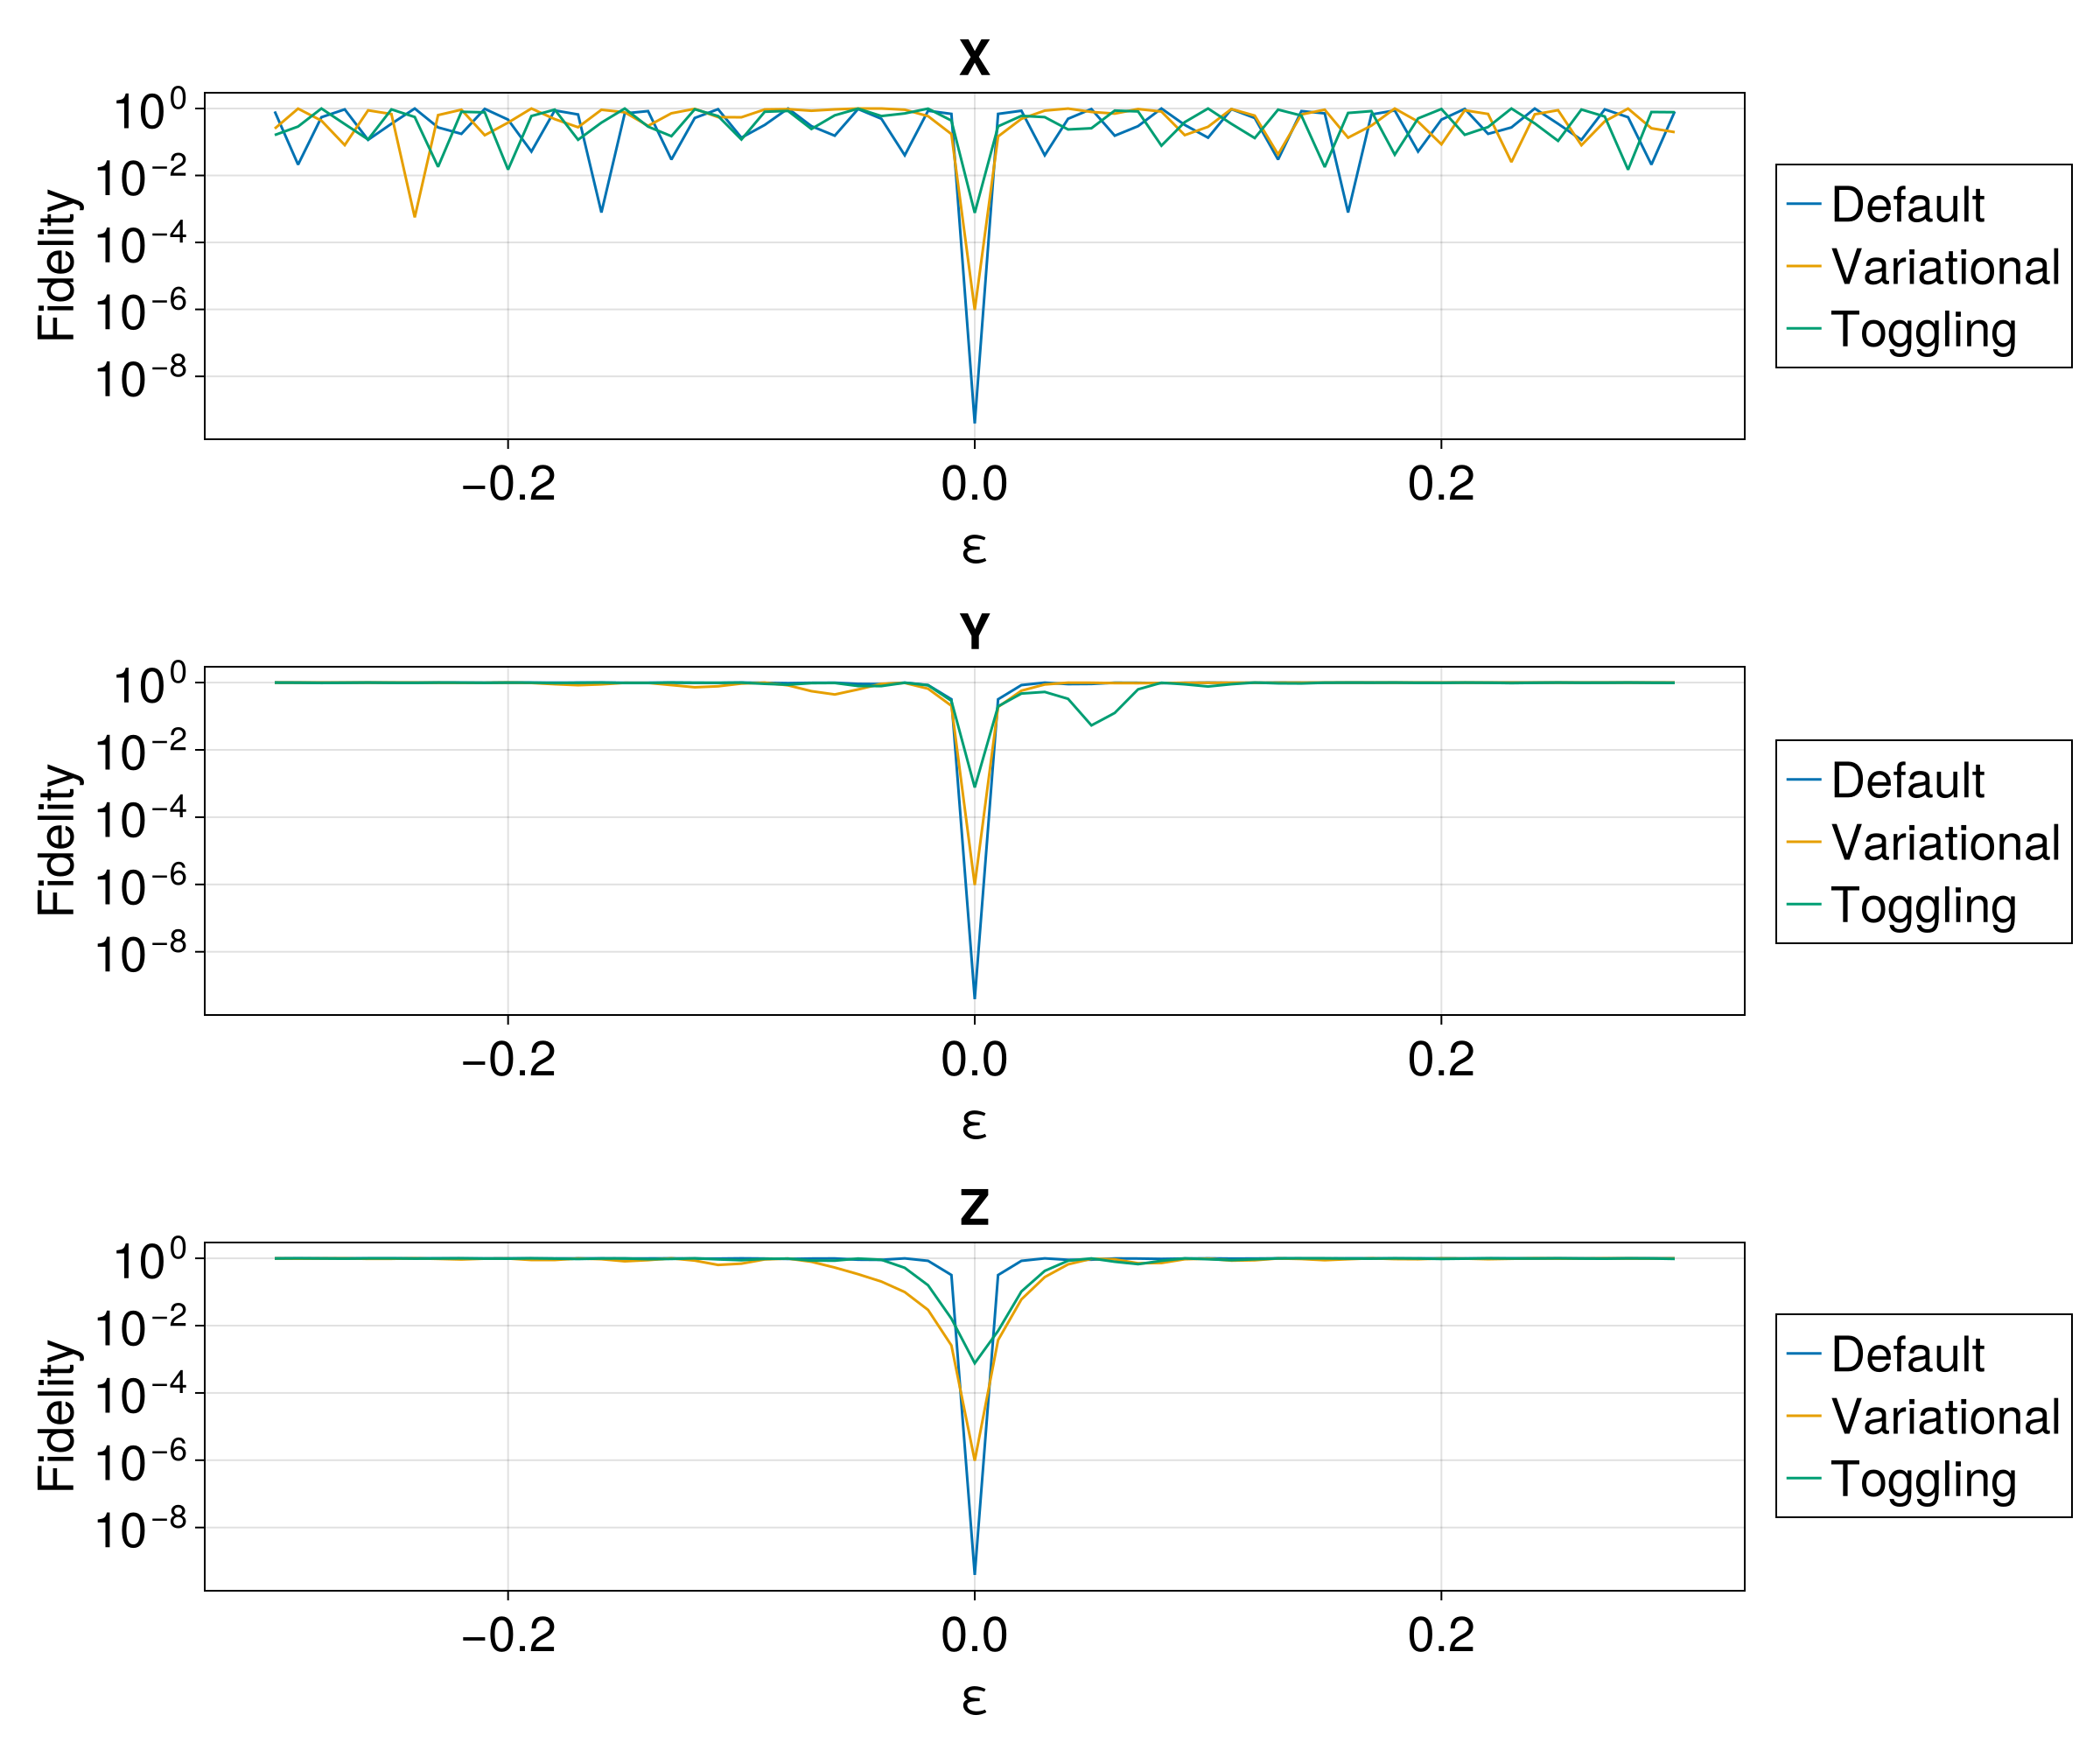

CairoMakie.Screen{IMAGE}


In [123]:
H_drive_add = H_drive  # (kept from your snippet, though it's unused below)

f = Figure(fontsize = 28, size = (1200, 1000))
axX = Axis(f[1, 1], title = "X", xlabel = "ε", ylabel = "Fidelity", yscale = log10)
axY = Axis(f[2, 1], title = "Y", xlabel = "ε", ylabel = "Fidelity", yscale = log10)
axZ = Axis(f[3, 1], title = "Z", xlabel = "ε", ylabel = "Fidelity", yscale = log10)

colors = Makie.wong_colors()
εs = -0.3:0.01:0.3

gen = [PAULIS.X, PAULIS.Y]

axes_paulis = [
    (axX, PAULIS.X),
    (axY, PAULIS.Y),
    (axZ, PAULIS.Z),
]

problems = [
    (def,        "Default"),
    (varadd_prob, "Variational"),
    (add_prob, "Toggling"),
    #(f_uni_prob,   "Universal"),
    # (f_uni_prob, "fast universal"),
    # (rf_uni_prob,"really fast universal"),
]

# Helper to compute the curve once per (problem, Pauli)
fidelity_curve(prob, pauli) = [unitary_rollout_fidelity(prob.trajectory, QuantumSystem(ε * pauli, gen)) for ε in εs]

# Plot everything with two compact loops
for (ax, pauli) in axes_paulis
    for (i, (prob, label)) in enumerate(problems)
        ys = norm.(fidelity_curve(prob, pauli) .- 1)
        lines!(ax, εs, ys; label = label, color = colors[i], linestyle = :solid)
    end
end

Legend(f[1, 2], axX, position = :lb)
Legend(f[2, 2], axY, position = :lb)
Legend(f[3, 2], axZ, position = :lb)

display(f)


In [124]:
u_x = add_prob.trajectory.a[1,:]
u_y = add_prob.trajectory.a[2,:]

50-element Vector{Float64}:
  0.0
 -0.016761385136684882
 -0.020208196034193403
 -0.031024119889298863
 -0.026744382686811518
 -0.029481574547387188
 -0.027794308784855577
 -0.02709884132696912
 -0.024880431341590792
 -0.025259861604367505
  ⋮
 -0.026378867133374236
 -0.024376399808738007
 -0.022160179229843712
 -0.012425649230164737
 -0.016244951800239563
 -0.014996417998053173
 -0.02457939035128863
  0.014714438183643852
  0.0

In [125]:
using FFTW

"""
Return FFT frequency axis (Hz) for length N and timestep dt (s),
matching the ordering of fft(u).
"""
function fftfreq(N::Int, dt::Float64)
    df = 1.0 / (N * dt)
    freqs = [k <= N ÷ 2 ? k : k - N for k in 0:N-1]  # integer bins
    return df .* freqs
end

"""
Gaussian amplitude response with given -3 dB bandwidth B3dB (Hz).

|G(f)| = exp( - f^2 / (2 σ_f^2) ), with σ_f = B3dB / sqrt(log(2)).
"""
function gaussian_filter(freqs::AbstractVector{<:Real}, B3dB::Float64)
    σf = B3dB / sqrt(log(2.0))
    return @. exp(-0.5 * (freqs^2) / σf^2)
end

gaussian_filter

In [126]:
import Pkg; Pkg.add("FFTW")

In [127]:
Δt

2.0

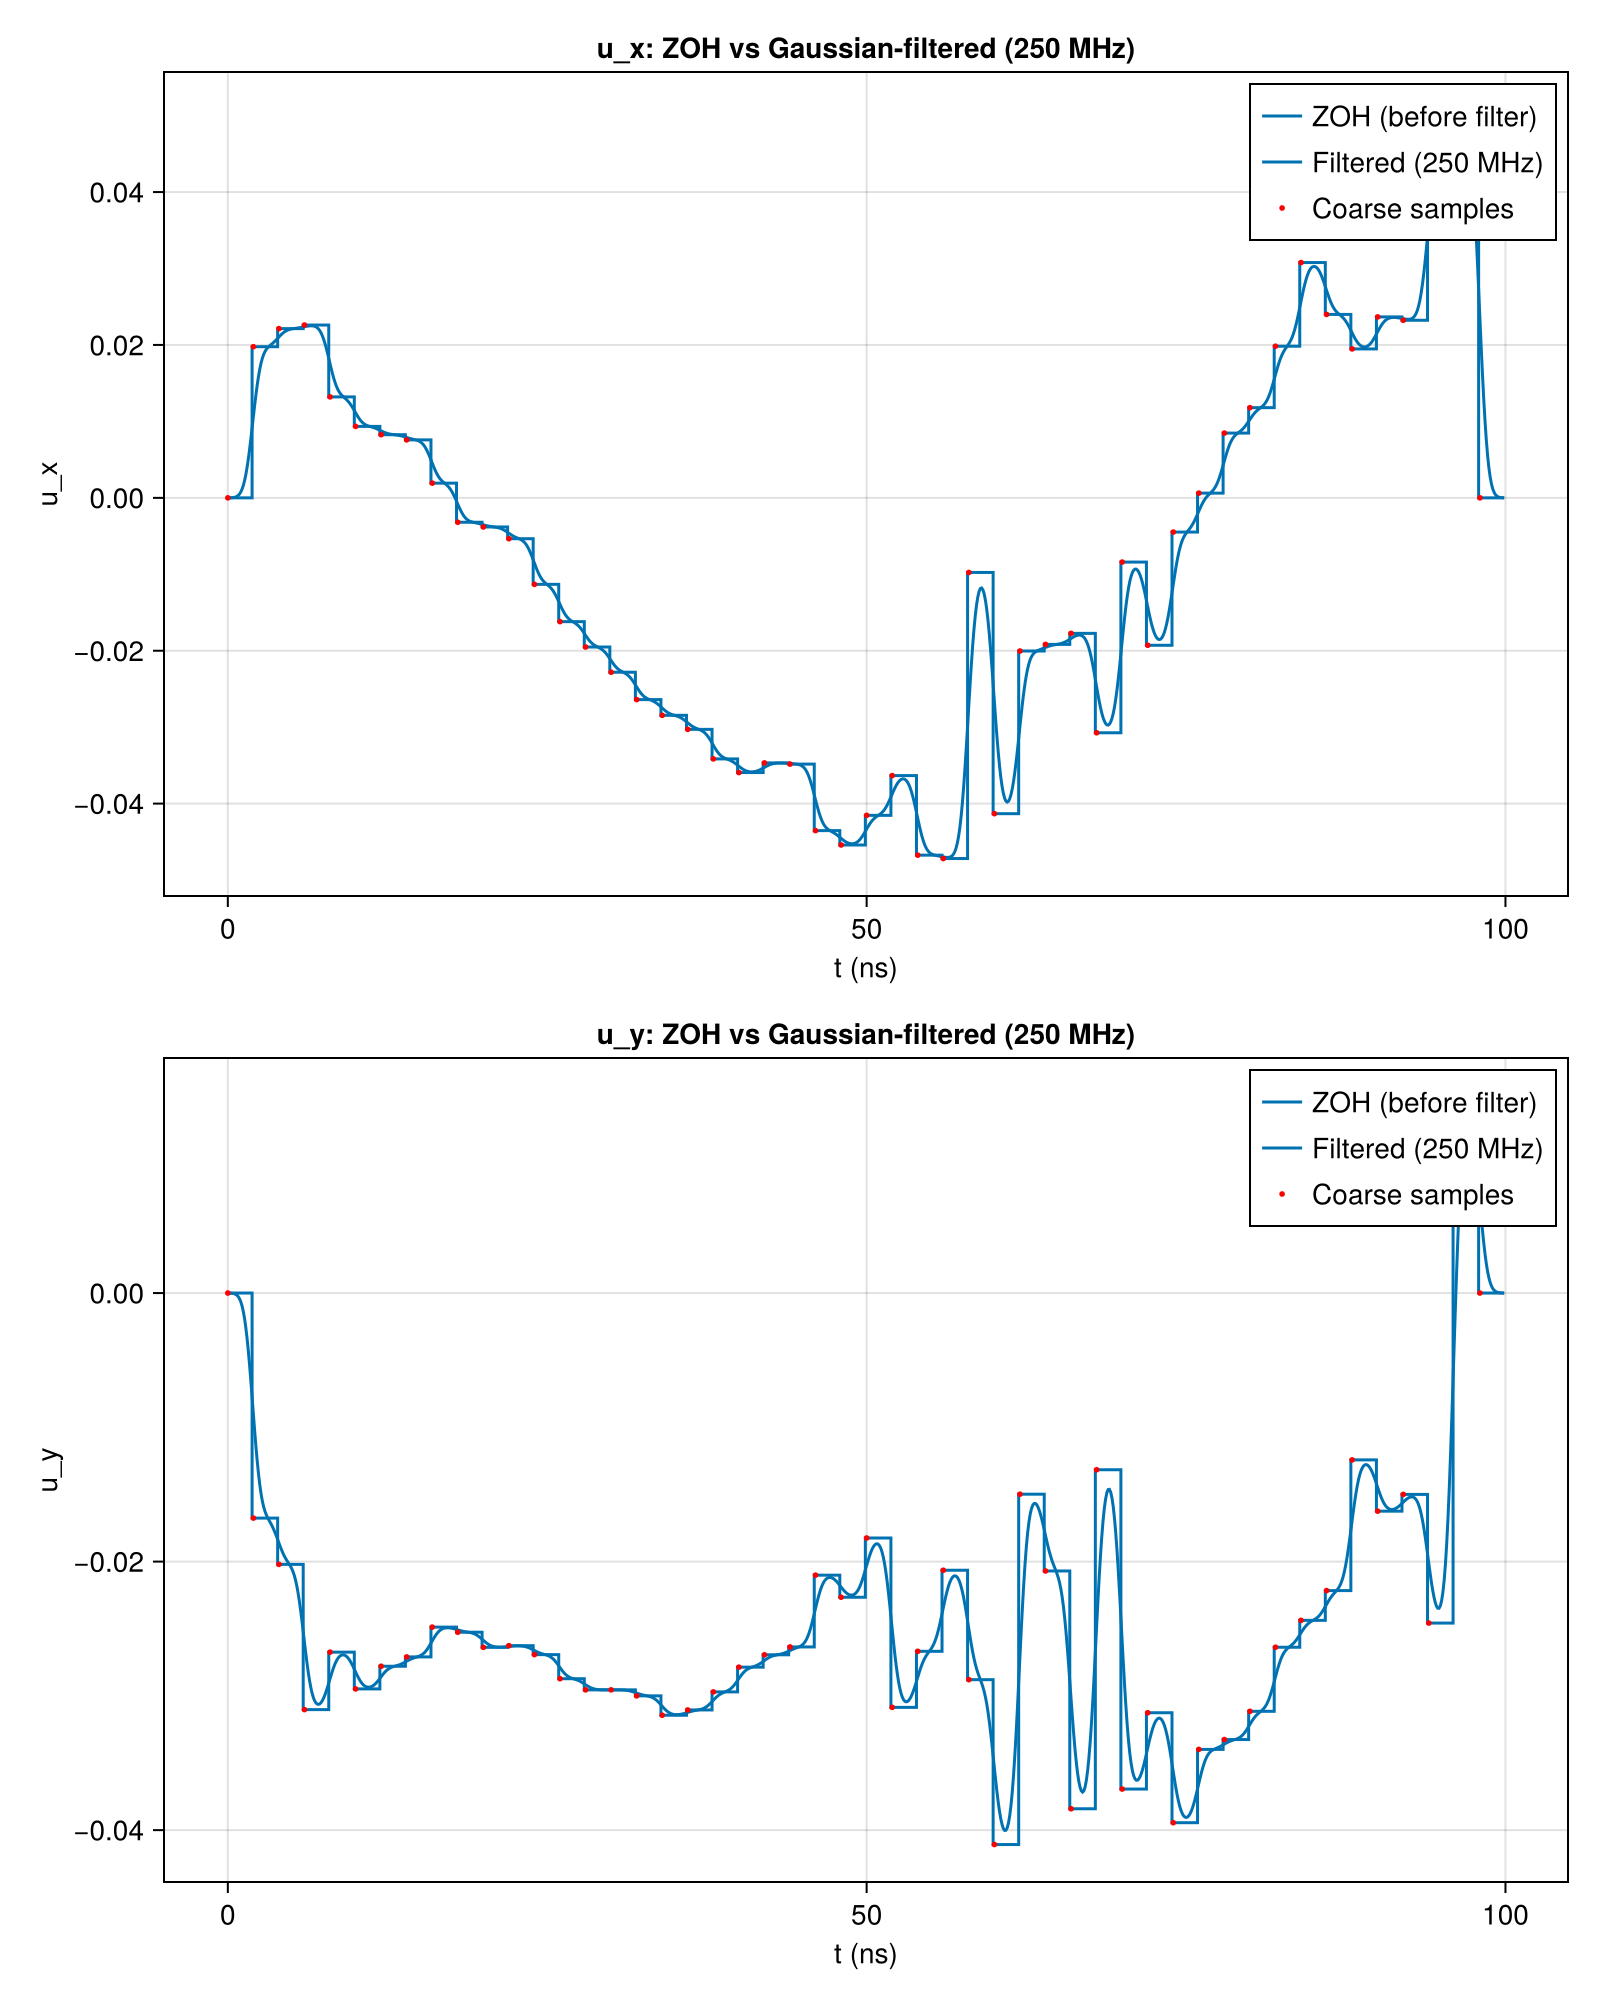

In [128]:
using FFTW
using CairoMakie

# -----------------------------
# 0. Data
# -----------------------------
u_x_coarse = add_prob.trajectory.a[1, :]
u_y_coarse = add_prob.trajectory.a[2, :]

dt_coarse = Δt*1e-9       # <-- set this to your real timestep [s], e.g. 1 ns
M = 20                    # upsampling factor
dt = dt_coarse / M       # fine timestep

N_coarse = length(u_x_coarse)

# -----------------------------
# 1. ZOH upsampling (before filtering)
# -----------------------------
u_x_zoh = repeat(u_x_coarse, inner = (M,))
u_y_zoh = repeat(u_y_coarse, inner = (M,))

N_fine = length(u_x_zoh)

t_coarse = (0:N_coarse-1) .* dt_coarse .* 1e9   # ns
t_fine   = (0:N_fine-1)   .* dt        .* 1e9   # ns

# Bundle into complex control for filtering
u_zoh = u_x_zoh .+ 1im .* u_y_zoh

# -----------------------------
# 2. Frequency axis + Gaussian filter
# -----------------------------
function fftfreq(N::Int, dt::Float64)
    df = 1.0 / (N * dt)
    freqs = [k <= N ÷ 2 ? k : k - N for k in 0:N-1]
    return df .* freqs
end

function gaussian_filter(freqs, B3dB_Hz)
    σf = B3dB_Hz / sqrt(log(2.0))         # σ_f = B_3dB / sqrt(ln 2)
    @. exp(-0.5 * (freqs^2) / σf^2)
end

freqs = fftfreq(N_fine, dt)

B3_250 = 250e6                            # 250 MHz -3 dB
G250   = gaussian_filter(freqs, B3_250)

# Hardware response S(f) (replace with real measured spectrum later)
S_meas = ones(ComplexF64, N_fine)        # flat for now
eps = 0.0
S_safe = S_meas .+ eps

# -----------------------------
# 3. FFT → (G / S) → IFFT
# -----------------------------
U = fft(u_zoh)

U_out_250 = G250 .* U ./ S_safe
u_out_250 = ifft(U_out_250)

u_x_250 = real.(u_out_250)
u_y_250 = imag.(u_out_250)

# -----------------------------
# 4. Plot with CairoMakie
# -----------------------------
CairoMakie.activate!()

# Subsample coarse points for plotting so they don't overwhelm the figure
stride = max(1, Int(floor(N_coarse / 100)))   # aim for ~100 coarse points
idx_coarse = 1:stride:N_coarse

fig = Figure(resolution = (800, 1000))

# ----- u_x -----
ax1 = Axis(fig[1, 1],
    xlabel = "t (ns)",
    ylabel = "u_x",
    title = "u_x: ZOH vs Gaussian-filtered (250 MHz)",
)

# ZOH before filtering (step-like)
stairs!(ax1, t_fine, u_x_zoh, label = "ZOH (before filter)")

# After filtering
lines!(ax1, t_fine, u_x_250, label = "Filtered (250 MHz)")

# Coarse samples (small, sparse)
scatter!(
    ax1,
    t_coarse[idx_coarse],
    u_x_coarse[idx_coarse],
    color = :red,
    markersize = 4,
    label = "Coarse samples"
)

axislegend(ax1, position = :rt)

# ----- u_y -----
ax2 = Axis(fig[2, 1],
    xlabel = "t (ns)",
    ylabel = "u_y",
    title = "u_y: ZOH vs Gaussian-filtered (250 MHz)",
)

stairs!(ax2, t_fine, u_y_zoh, label = "ZOH (before filter)")
lines!(ax2, t_fine, u_y_250, label = "Filtered (250 MHz)")

scatter!(
    ax2,
    t_coarse[idx_coarse],
    u_y_coarse[idx_coarse],
    color = :red,
    markersize = 4,
    label = "Coarse samples"
)

axislegend(ax2, position = :rt)

fig
# save("controls_zoh_vs_filtered.png", fig)

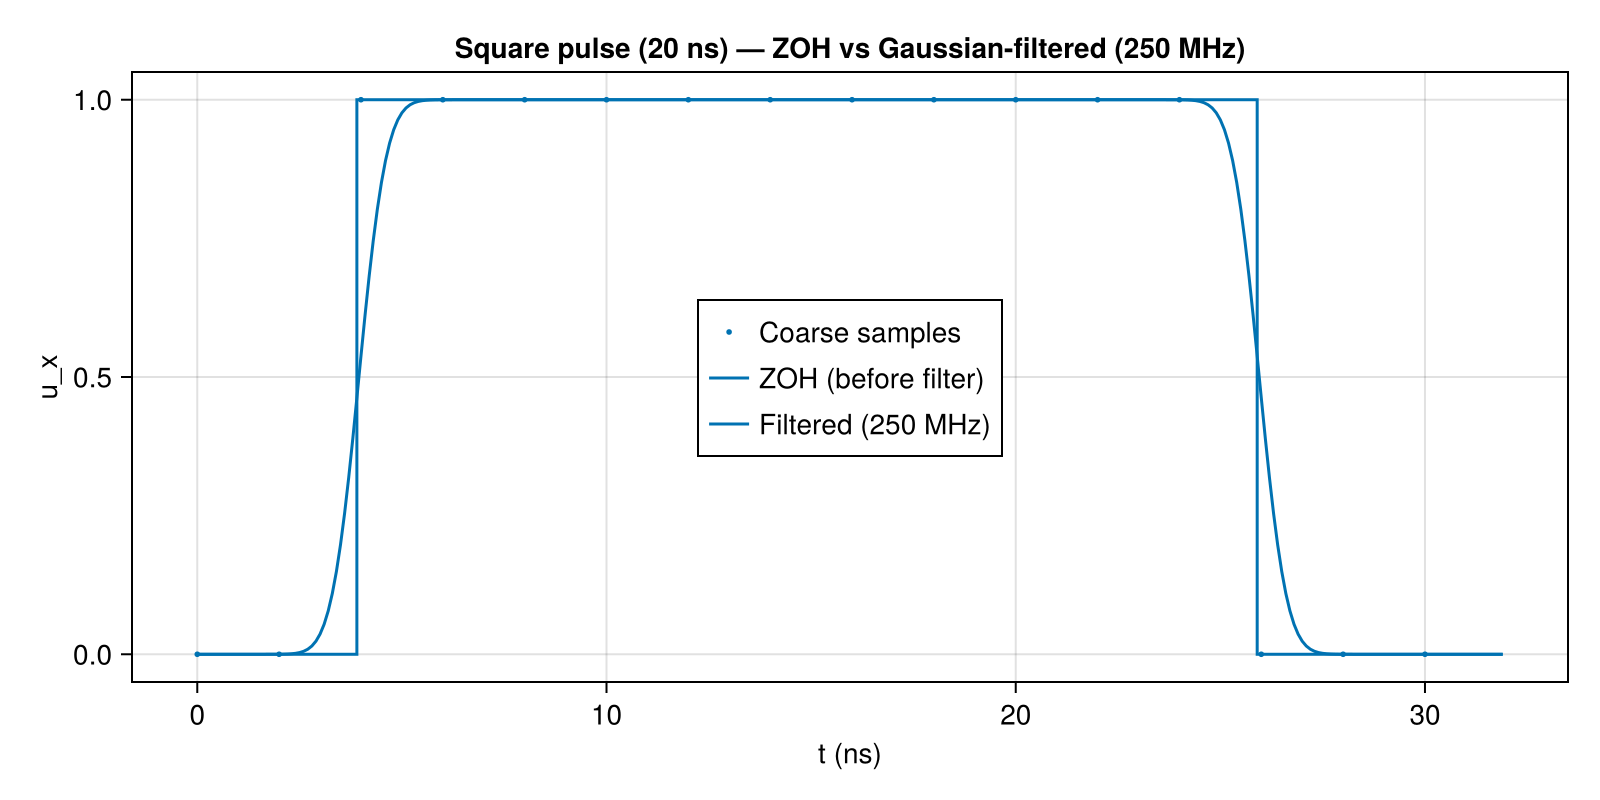

In [130]:
using FFTW
using CairoMakie

# ============================================
# Square-wave sanity check (20 ns wide pulse)
# Total duration ~30 ns
# ============================================

# --- Coarse time grid ---
sq_dt_coarse = 2.0e-9              # 2 ns
sq_T_total   = 30e-9               # 30 ns total window
sq_N_coarse  = Int(round(sq_T_total / sq_dt_coarse)) + 1

sq_t_coarse = (0:sq_N_coarse-1) .* sq_dt_coarse .* 1e9   # ns

# --- Coarse square pulse: width ~20 ns on X, Y = 0 ---
sq_u_x_coarse = zeros(Float64, sq_N_coarse)
sq_u_y_coarse = zeros(Float64, sq_N_coarse)

sq_pulse_width = 20e-9            # 20 ns
sq_pulse_start = 5e-9             # start at 5 ns
sq_pulse_end   = sq_pulse_start + sq_pulse_width  # end at 25 ns

sq_i_start = Int(floor(sq_pulse_start / sq_dt_coarse)) + 1
sq_i_end   = Int(floor(sq_pulse_end   / sq_dt_coarse)) + 1   # approx width 20 ns

sq_u_x_coarse[sq_i_start:sq_i_end] .= 1.0   # unit square pulse in X

# --- Upsampling ---
sq_M  = 20                         # upsampling factor
sq_dt = sq_dt_coarse / sq_M        # fine timestep

sq_u_x_zoh = repeat(sq_u_x_coarse, inner = (sq_M,))
sq_u_y_zoh = repeat(sq_u_y_coarse, inner = (sq_M,))

sq_N_fine = length(sq_u_x_zoh)
sq_t_fine = (0:sq_N_fine-1) .* sq_dt .* 1e9   # ns

sq_u_zoh = sq_u_x_zoh .+ 1im .* sq_u_y_zoh    # complex envelope

# --- Frequency axis + Gaussian 250 MHz filter ---
function sq_fftfreq(N::Int, dt::Float64)
    df = 1.0 / (N * dt)
    freqs = [k <= N ÷ 2 ? k : k - N for k in 0:N-1]
    return df .* freqs
end

function sq_gaussian_filter(freqs, B3dB_Hz)
    σf = B3dB_Hz / sqrt(log(2.0))    # –3 dB in power at B3dB_Hz
    @. exp(-0.5 * (freqs^2) / σf^2)
end

sq_freqs  = sq_fftfreq(sq_N_fine, sq_dt)
sq_B3_250 = 250e6                       # 250 MHz -3 dB
sq_G250   = sq_gaussian_filter(sq_freqs, sq_B3_250)

sq_S_meas = ones(ComplexF64, sq_N_fine)    # flat hardware for sanity check
sq_S_safe = sq_S_meas                      # no eps needed here

# --- FFT → filter → IFFT ---
sq_U         = fft(sq_u_zoh)
sq_U_out_250 = sq_G250 .* sq_U ./ sq_S_safe
sq_u_out_250 = ifft(sq_U_out_250)

sq_u_x_250 = real.(sq_u_out_250)
sq_u_y_250 = imag.(sq_u_out_250)

# --- Plot ---
CairoMakie.activate!()

sq_stride     = max(1, Int(floor(sq_N_coarse / 100)))
sq_idx_coarse = 1:sq_stride:sq_N_coarse

sq_fig = Figure(resolution = (800, 400))

sq_ax1 = Axis(sq_fig[1, 1],
    xlabel = "t (ns)",
    ylabel = "u_x",
    title  = "Square pulse (20 ns) — ZOH vs Gaussian-filtered (250 MHz)",
)

# coarse samples
scatter!(sq_ax1, sq_t_coarse[sq_idx_coarse], sq_u_x_coarse[sq_idx_coarse],
         markersize = 4, label = "Coarse samples")

# ZOH (staircase)
stairs!(sq_ax1, sq_t_fine, sq_u_x_zoh, label = "ZOH (before filter)")

# filtered
lines!(sq_ax1, sq_t_fine, sq_u_x_250, label = "Filtered (250 MHz)")

axislegend(sq_ax1, position = :cc)

sq_fig
# save("square_pulse_zoh_vs_filtered_30ns.png", sq_fig)

In [131]:
using QuantumToolbox
# ----------------------------------------------------------
# 0. Controls and time grid
# ----------------------------------------------------------
dt *= 1e9  # convert to ns for plotting
N  = length(u_x_zoh)
@assert length(u_y_zoh) == N


T  = (N - 1) * dt
tlist = collect(0.0:dt:T)   # times where we want states

# ----------------------------------------------------------
# 1. Single-qubit operators
# ----------------------------------------------------------
sx = sigmax()
sy = sigmay()

# ----------------------------------------------------------
# 2. ZOH coefficient functions for u_x, u_y
#    Signature must be (p, t) even if p is unused.
# ----------------------------------------------------------
function ux_coef(p, t)
    t_clamped = clamp(t, 0, T)
    idx = Int(floor(t_clamped / dt)) + 1
    return u_x_zoh[idx]
end

function uy_coef(p, t)
    t_clamped = clamp(t, 0, T)
    idx = Int(floor(t_clamped / dt)) + 1
    return u_y_zoh[idx]
end

# ----------------------------------------------------------
# 3. Time-dependent Hamiltonian:
#    H(t) = 0.5 * u_x(t) * σx + 0.5 * u_y(t) * σy
#    (adjust 0.5 / 2π etc to match your convention)
# ----------------------------------------------------------
H_t = QobjEvo((
    (sx, ux_coef),
    (sy, uy_coef),
))

# You can check this now:
# H_t(0.0)    # <- should return a 2x2 QuantumObject, no error

# ----------------------------------------------------------
# 4. Evolve basis states |0>, |1>
# ----------------------------------------------------------
ψ0 = basis(2, 0)   # |0>
ψ1 = basis(2, 1)   # |1>

sol0 = sesolve(H_t, ψ0, tlist; progress_bar = Val(false))
sol1 = sesolve(H_t, ψ1, tlist; progress_bar = Val(false))

ψT_0 = sol0.states[end]   # final |ψ(T)⟩ from |0>
ψT_1 = sol1.states[end]   # final |ψ(T)⟩ from |1>

# ----------------------------------------------------------
# 5. Build the final unitary U(T)
#    Columns: U(T)|0>, U(T)|1>
# ----------------------------------------------------------
v0 = ψT_0.data   # 2-element vector
v1 = ψT_1.data

U_mat = hcat(v0, v1)   # 2x2 Matrix{ComplexF64}

U_T   = QuantumObject(U_mat)


Quantum Object:   type=Operator()   dims=[2]   size=(2, 2)   ishermitian=false
2×2 Matrix{ComplexF64}:
 0.00368945-0.0270871im  -0.00251442+0.999623im
 0.00251442+0.999623im    0.00368945+0.0270871im

In [132]:
had = QuantumObject(GATES.H)
abs(tr(had'U_T) / 2)

0.6876868050341192

In [133]:
unitary_rollout_fidelity(varadd_prob.trajectory, QuantumSystem(0.0 * GATES.Z, gen))

0.9999990321548081

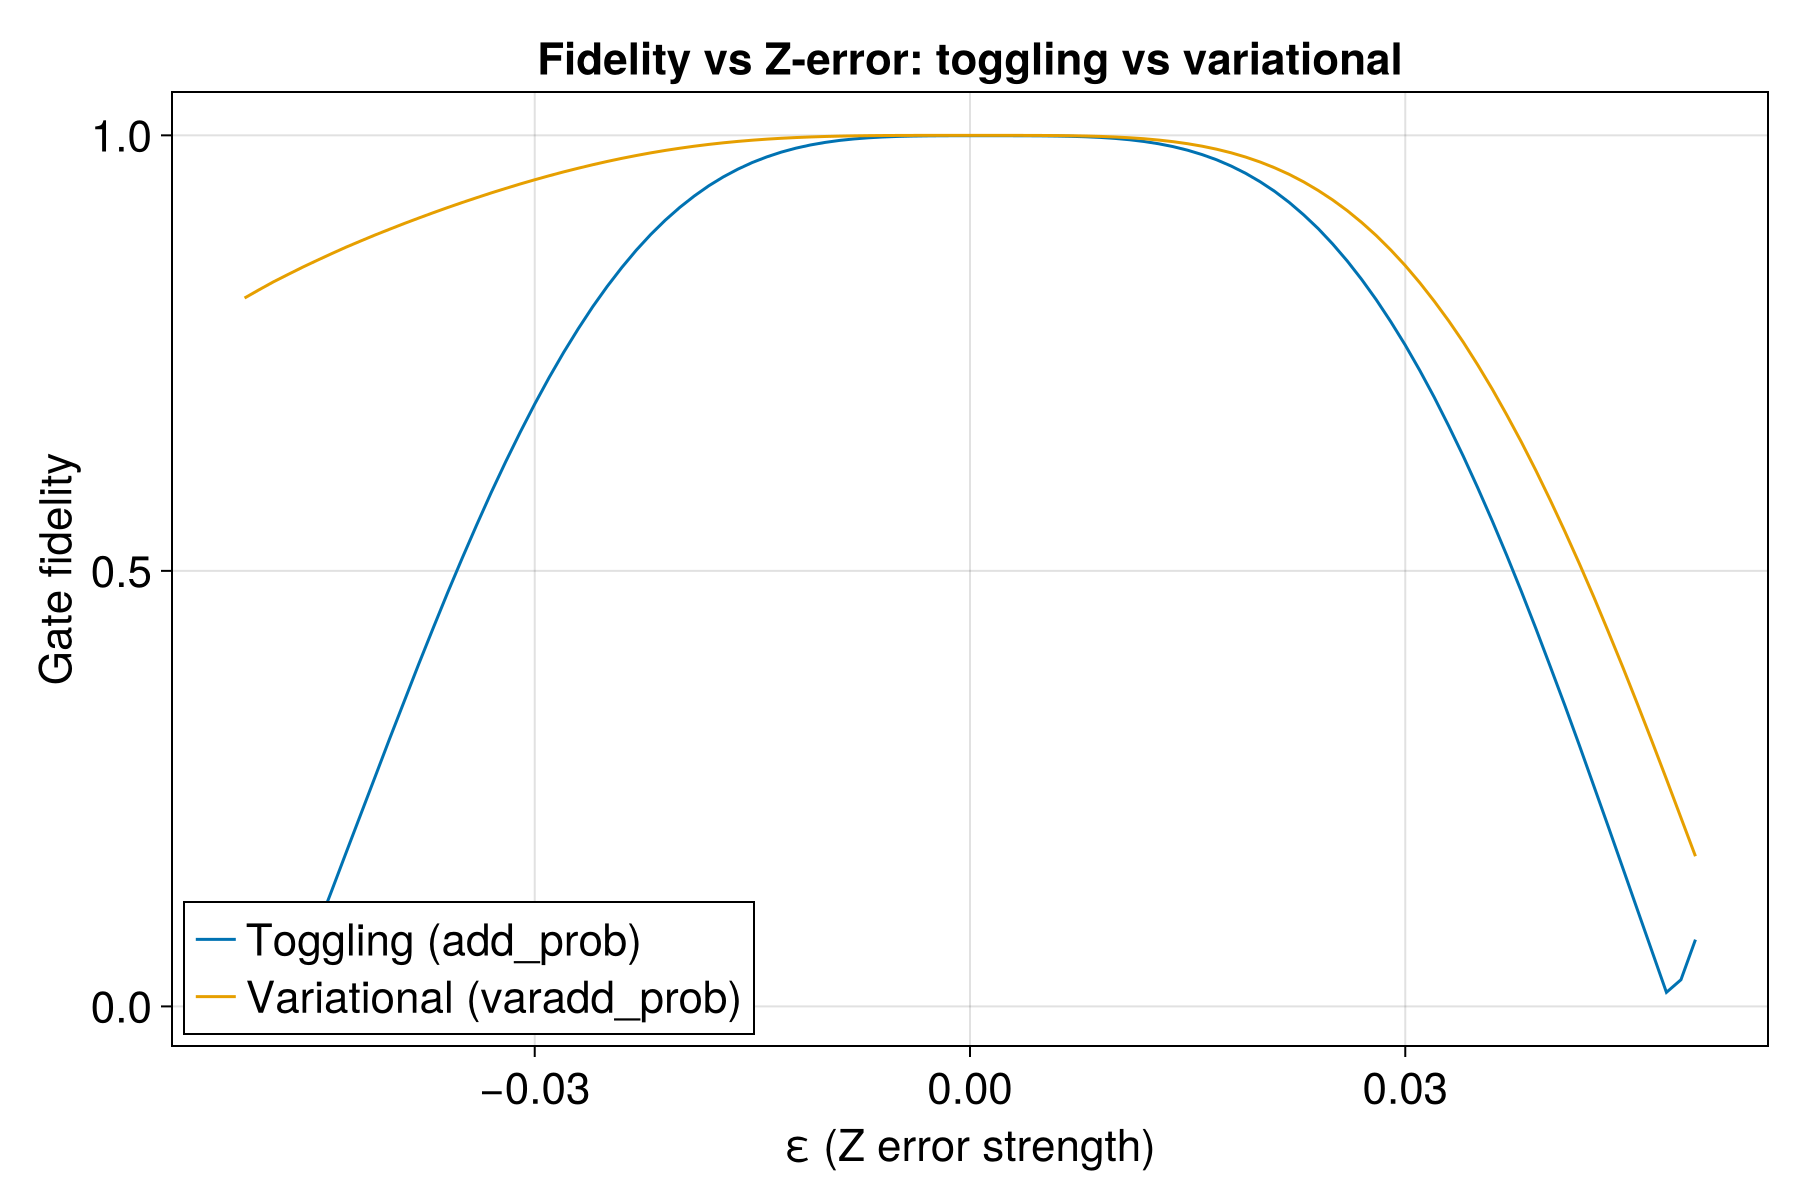

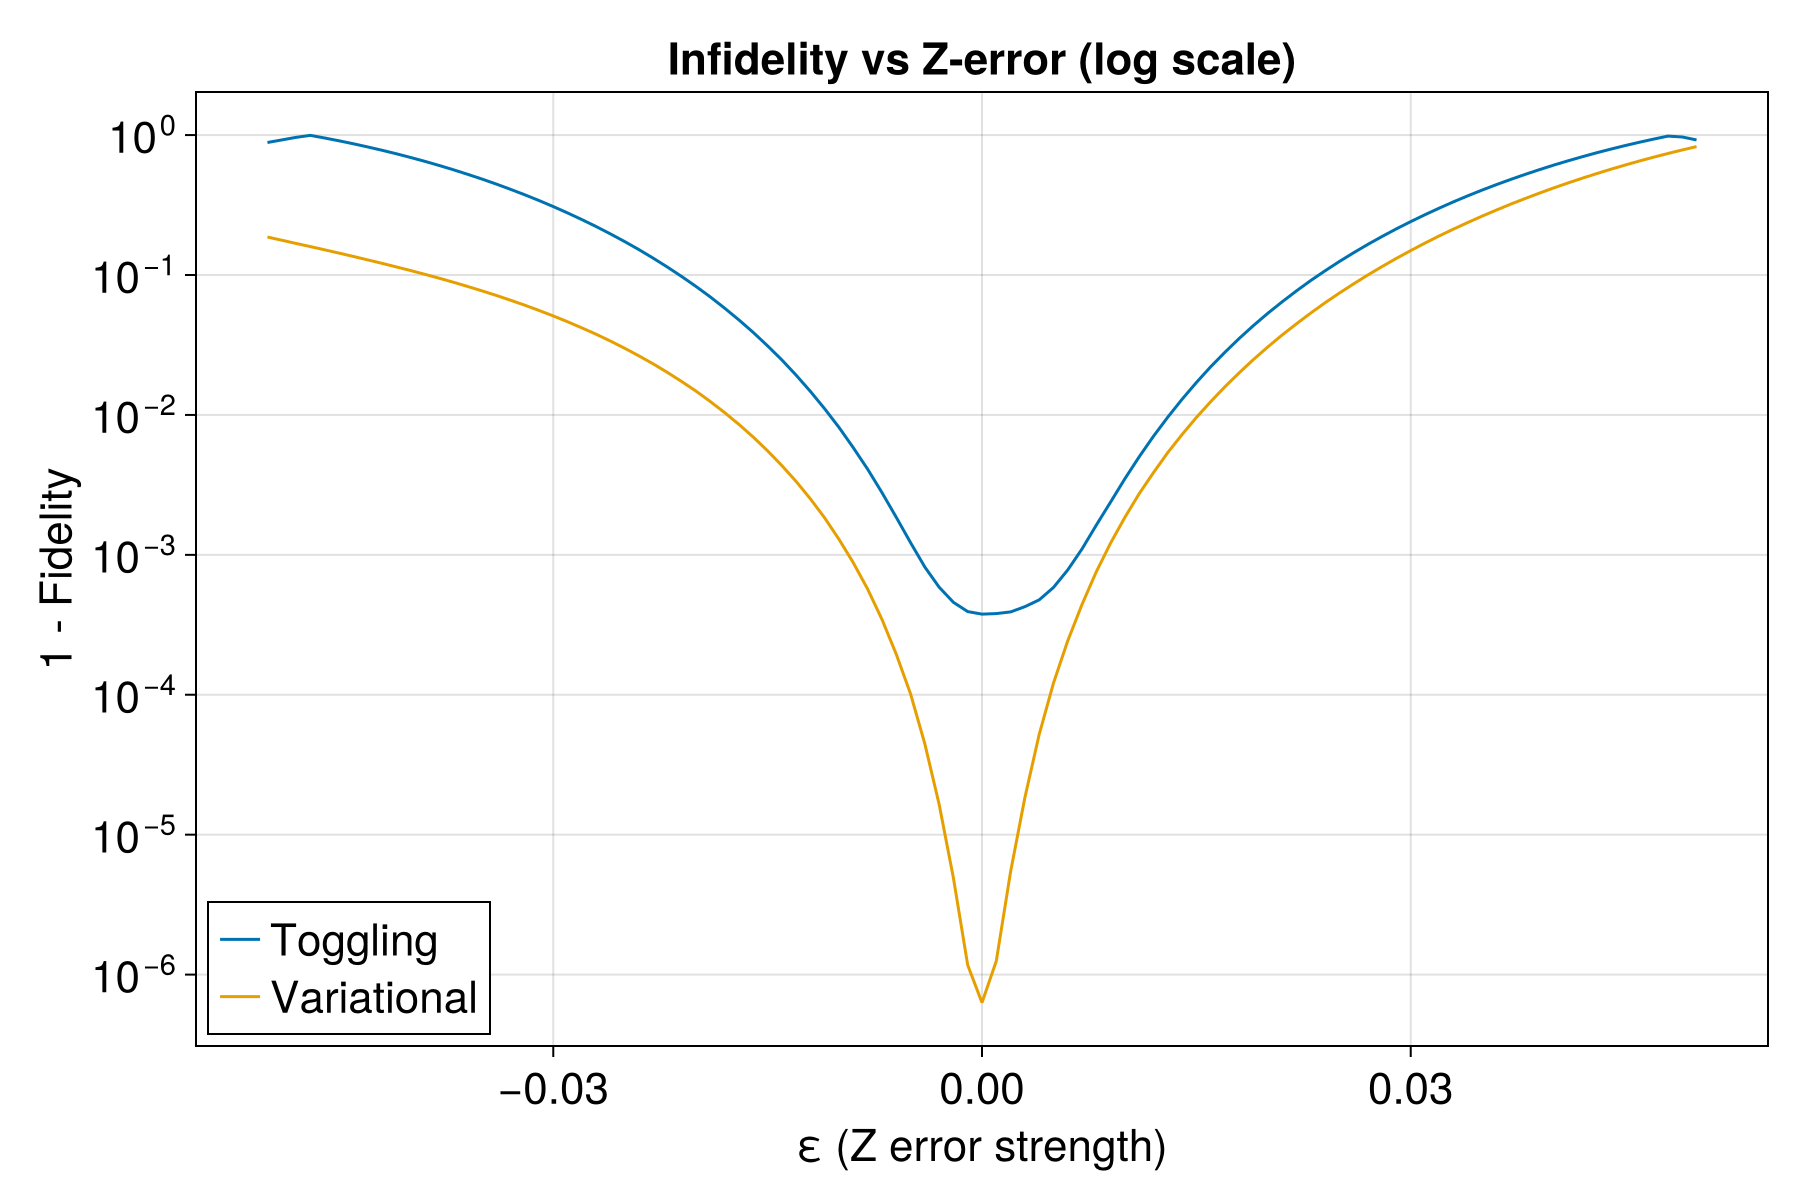

CairoMakie.Screen{IMAGE}


In [134]:
using QuantumToolbox
using CairoMakie

const QT = QuantumToolbox  # avoid any name shadowing

# ----------------------------------------------------------
# Helper: simulate fidelity for one set of controls & εZ error
# ----------------------------------------------------------
"""
Simulate the unitary for controls u_x(t), u_y(t) with timestep dt and
constant Z-error ε, using

    H(t) = u_x(t) σ_x + u_y(t) σ_y + ε σ_z

and return the single-qubit gate fidelity to target Hadamard H:

    F = |Tr(H† U(T))| / 2
"""
function simulate_fidelity_for_controls(u_x::AbstractVector,
                                        u_y::AbstractVector,
                                        dt::Real,
                                        ε::Real,
                                        had_q::QT.QuantumObject)

    N = length(u_x)
    @assert length(u_y) == N "u_x and u_y must have same length"

    dt_f = Float64(dt)
    T    = (N - 1) * dt_f
    tlist = collect(0.0:dt_f:T)

    sx = QT.sigmax()
    sy = QT.sigmay()
    sz = QT.sigmaz()

    # ZOH coefficients for controls
    function ux_coef(p, t)
        t_clamped = clamp(t, 0.0, T)
        idx       = Int(floor(t_clamped / dt_f)) + 1
        return u_x[idx]
    end

    function uy_coef(p, t)
        t_clamped = clamp(t, 0.0, T)
        idx       = Int(floor(t_clamped / dt_f)) + 1
        return u_y[idx]
    end

    # Constant Z-error coefficient
    function uz_coef(p, t)
        return ε
    end

    # H(t) = u_x(t) σ_x + u_y(t) σ_y + ε σ_z
    H_t = QT.QobjEvo((
        (sx, ux_coef),
        (sy, uy_coef),
        (sz, uz_coef),
    ))

    ψ0 = QT.basis(2, 0)
    ψ1 = QT.basis(2, 1)

    sol0 = QT.sesolve(H_t, ψ0, tlist; progress_bar = Val(false))
    sol1 = QT.sesolve(H_t, ψ1, tlist; progress_bar = Val(false))

    ψT_0 = sol0.states[end]
    ψT_1 = sol1.states[end]

    v0 = ψT_0.data
    v1 = ψT_1.data
    U_T = hcat(v0, v1)               # 2×2 matrix

    U_q = QT.QuantumObject(U_T)
    F   = abs(tr(had_q' * U_q)) / 2  # single-qubit gate fidelity
    return F
end

# ----------------------------------------------------------
# 1. Extract controls from both problems
# ----------------------------------------------------------

# Toggling objective (add_prob)
u_x_add = add_prob.trajectory.a[1, :]
u_y_add = add_prob.trajectory.a[2, :]
Δt_add  = Float64(add_prob.trajectory.Δt[1])   # should be 2.0

# Adjoint/variational objective (varadd_prob)
u_x_var = varadd_prob.trajectory.a[1, :]
u_y_var = varadd_prob.trajectory.a[2, :]
Δt_var  = Float64(varadd_prob.trajectory.Δt[1])  # should also be 2.0

# ----------------------------------------------------------
# 2. Define target gate and ε-range
# ----------------------------------------------------------
had_q = QT.QuantumObject(GATES.X)  # Hadamard from PiccoloQuantumObjects

εs = collect(-0.05:0.001:0.05)    # Z-error strengths

F_add = similar(εs, Float64)
F_var = similar(εs, Float64)

# ----------------------------------------------------------
# 3. Sweep ε and compute fidelities
# ----------------------------------------------------------
for (i, ε) in enumerate(εs)
    F_add[i] = simulate_fidelity_for_controls(u_x_add, u_y_add, Δt_add, ε, had_q)
    F_var[i] = simulate_fidelity_for_controls(u_x_var, u_y_var, Δt_var, ε, had_q)
    println("iteration $i / $(length(εs)): ε = $ε, F_add = $(F_add[i]), F_var = $(F_var[i])")
end

# ----------------------------------------------------------
# 4. Plot fidelity vs ε for both methods
# ----------------------------------------------------------
CairoMakie.activate!()

fig1 = Figure(resolution = (900, 600), fontsize = 22)
ax1  = Axis(fig1[1, 1],
    xlabel = "ε (Z error strength)",
    ylabel = "Gate fidelity",
    title  = "Fidelity vs Z-error: toggling vs variational"
)

lines!(ax1, εs, F_add, label = "Toggling (add_prob)")
lines!(ax1, εs, F_var, label = "Variational (varadd_prob)")

axislegend(ax1, position = :lb)
display(fig1)

# Optionally: plot infidelity on log scale
fig2 = Figure(resolution = (900, 600), fontsize = 22)
ax2  = Axis(fig2[1, 1],
    xlabel = "ε (Z error strength)",
    ylabel = "1 - Fidelity",
    yscale = log10,
    title  = "Infidelity vs Z-error (log scale)"
)

lines!(ax2, εs, 1 .- F_add, label = "Toggling")
lines!(ax2, εs, 1 .- F_var, label = "Variational")

axislegend(ax2, position = :lb)
display(fig2)

# You can save if you like:
# save("fidelity_vs_epsilon_add_vs_var.png", fig1)
# save("infidelity_vs_epsilon_add_vs_var_log.png", fig2)

In [135]:
function var_obj(
    traj::NamedTrajectory, 
    H_drives::Vector{Matrix{ComplexF64}}, 
    H_errors::Vector{Matrix{ComplexF64}}
)
    Δt = traj.Δt[1]
    T = traj.T
    varsys = VariationalQuantumSystem(H_drives, H_errors)
    Ũ⃗, ∂Ũ⃗ = variational_unitary_rollout(traj, varsys)

    U = iso_vec_to_operator(Ũ⃗[:, end])
    # First error term
    ∂U = iso_vec_to_operator(∂Ũ⃗[1][:, end])

    d = size(U, 1)
    return abs(tr((U'*∂U)'*(U'*∂U))) / (T * Δt)^2 / d
end

function tog_obj(
    traj::NamedTrajectory, 
    H_drives::Vector{Matrix{ComplexF64}},
    H_error::Matrix{ComplexF64}
)
    T = traj.T
    Δt = get_timesteps(traj)

    sys = QuantumSystem(H_drives)
    U = iso_vec_to_operator.(eachcol(unitary_rollout(traj, sys)))
    
    # Toggle integral
    H_ti = sum(Δt[i] .* U[i]' * H_error * U[i] for i=1:T-1)

    d₁ = size(U[1], 1)
    Δt₁ = Δt[1]
    metric = norm(tr(H_ti'H_ti)) / (T * Δt₁)^2 / d₁
    return metric
end

function commutator(A::AbstractMatrix{<:Number}, B::AbstractMatrix{<:Number})
    return A*B - B*A
end

function pert_tog_obj(
    traj::NamedTrajectory, 
    H_drives::Vector{Matrix{ComplexF64}},
    H_error::Matrix{ComplexF64};
    order::Int=1,
    a_bound::Float64=a_bound
)
    T = traj.T
    Δt = get_timesteps(traj)

    sys = QuantumSystem(H_drives)
    U = iso_vec_to_operator.(eachcol(unitary_rollout(traj, sys)))

    # toggle integral
    H_ti = zeros(ComplexF64, size(U[1]))

    # note: U_1 = I, so U[:, k] = U_{k-1}.
    # you need to go to T-1, only
    for k in 1:T-1
        Hₖ = sum(traj.a[l, k] / a_bound * H for (l, H) in enumerate(H_drives))
        adjⁿH_E = H_error
        Eₖ_n = H_error * Δt[k]
        
        # get the different orders of the Hadamard lemma
        for n in 2:order
            coef_n = ComplexF64(im^(n-1) * a_bound^(n-1) * Δt[k]^n / factorial(big(n)))
            adjⁿH_E = commutator(Hₖ, adjⁿH_E)
            # Eₖ_n = push!(Eₖ_n, coef_n * adjⁿH_E)
            Eₖ_n += coef_n * adjⁿH_E
        end

        # nth order toggle integral up to k
        H_ti += U[k]' * Eₖ_n * U[k]
    end

    d₁ = size(U[1], 1)
    Δt₁ = Δt[1]
    metric = norm(tr(H_ti'H_ti)) / (T * Δt₁)^2 / d₁
    return metric
end

pert_tog_obj (generic function with 1 method)

In [136]:
var_obj(
    varadd_prob.trajectory, 
    H_drive, 
    [PAULIS.Z]
)

2.9033400917600015e-9

In [137]:
var_obj(
    add_prob.trajectory, 
    H_drive, 
    [PAULIS.Z]
)

0.00030057602957329557

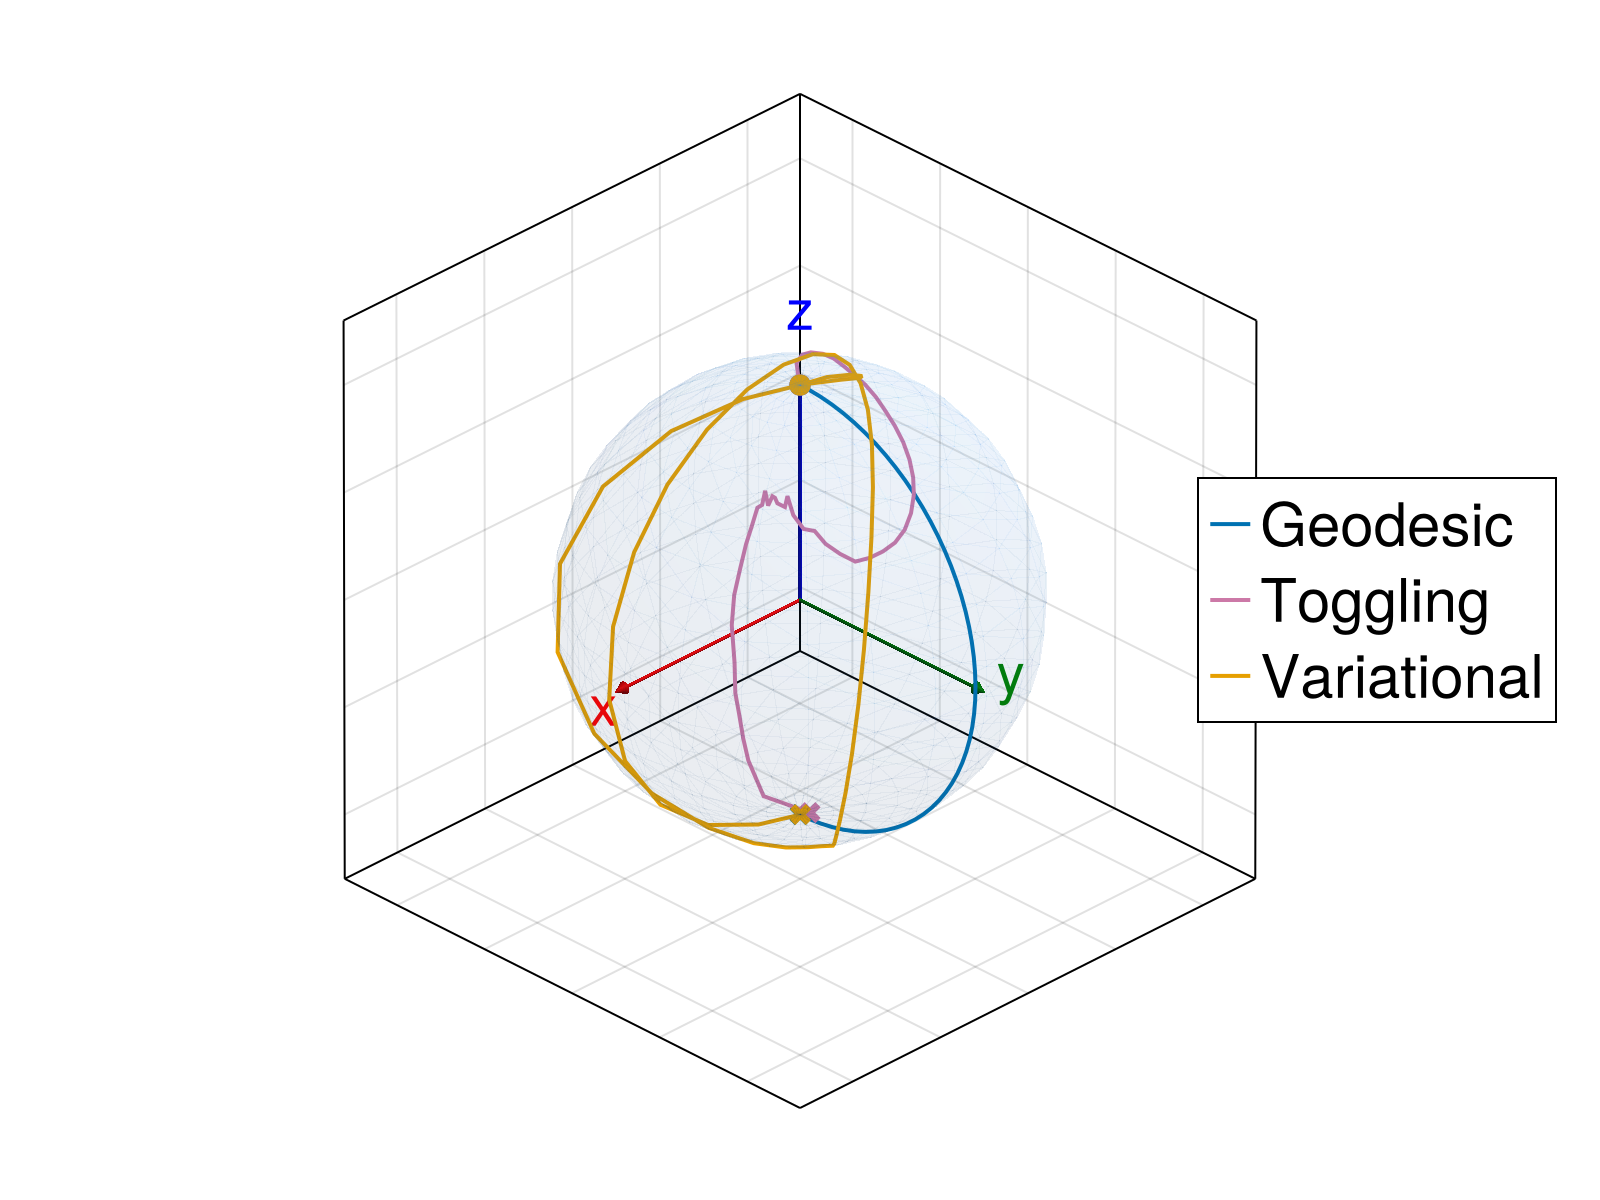

In [141]:
using CairoMakie
using GeometryBasics

default_traj = def.trajectory
tog_traj     = add_prob.trajectory
var_traj     = varadd_prob.trajectory


colors = [Makie.wong_colors()[1], Makie.wong_colors()[4], Makie.wong_colors()[2]]
ket_0 = [1.0,0.0]
traj_vec = [default_traj, tog_traj, var_traj]
labels = ["Geodesic", "Toggling", "Variational"]
rho_0 = ket_0 * ket_0'

f  = CairoMakie.Figure(resolution = (800, 600))
ax = CairoMakie.Axis3(f[1, 1];
    aspect = :equal
)

palette = to_colormap(:tab10)
styles  = (:solid, :dash, :dot, :dashdot)

origins = [Point3f(0,0,0), Point3f(0,0,0), Point3f(0,0,0)]
dirs    = [Vec3f(1.0,0,0), Vec3f(0,1.0,0), Vec3f(0,0,1.0)]

CairoMakie.arrows!(ax, origins, dirs;
    color = [:red, :green, :blue],
    arrowsize = 0.05,
    linewidth = 0.01
)

CairoMakie.text!(ax, "x", position = Point3f(1.2, 0, 0), align = (:left, :center),  color = :red,   fontsize = 28)
CairoMakie.text!(ax, "y", position = Point3f(0, 1.2, 0), align = (:center, :bottom), color = :green, fontsize = 28)
CairoMakie.text!(ax, "z", position = Point3f(0, 0, 1.2), align = (:center, :bottom), color = :blue,  fontsize = 28)

for (i, traj) in enumerate(traj_vec)
    expect_val_x = [real(tr(PAULIS.X * iso_vec_to_operator(traj.Ũ⃗[:, t]) * rho_0 * iso_vec_to_operator(traj.Ũ⃗[:, t])')) for t in 1:traj.T]
    expect_val_y = [real(tr(PAULIS.Y * iso_vec_to_operator(traj.Ũ⃗[:, t]) * rho_0 * iso_vec_to_operator(traj.Ũ⃗[:, t])')) for t in 1:traj.T]
    expect_val_z = [real(tr(PAULIS.Z * iso_vec_to_operator(traj.Ũ⃗[:, t]) * rho_0 * iso_vec_to_operator(traj.Ũ⃗[:, t])')) for t in 1:traj.T]

    CairoMakie.lines!(ax, real.(expect_val_x), real.(expect_val_y), real.(expect_val_z);
        color = colors[i],
        label = labels[i],
        #linestyle = styles[i],
        linewidth = 2.0
    )

    CairoMakie.scatter!(ax, [real(expect_val_x[end])], [real(expect_val_y[end])], [real(expect_val_z[end])];
        color = colors[i], markersize = 15, marker = :xcross)
    CairoMakie.scatter!(ax, [real(expect_val_x[1])], [real(expect_val_y[1])], [real(expect_val_z[1])];
        color = colors[i], markersize = 15)

end
CairoMakie.mesh!(ax, Sphere(Point3f(0,0,0), 1f0);
    color = (0.2, 0.6, 1.0, 0.05),
    transparency = true,
    shading = true
)

CairoMakie.xlims!(ax, -1.3, 1.3)
CairoMakie.ylims!(ax, -1.3, 1.3)
CairoMakie.zlims!(ax, -1.3, 1.3)

ax.azimuth[]   =  π/4
ax.elevation[] =  π/6

#CairoMakie.axislegend(ax; position = :rt, fontsize=40)
CairoMakie.hidexdecorations!(ax, grid = false)
CairoMakie.hideydecorations!(ax, grid = false)
CairoMakie.hidezdecorations!(ax, grid = false)

CairoMakie.axislegend(ax; position = :rc, labelsize = 30)
#save("modq_plot.png", f)
f  
     

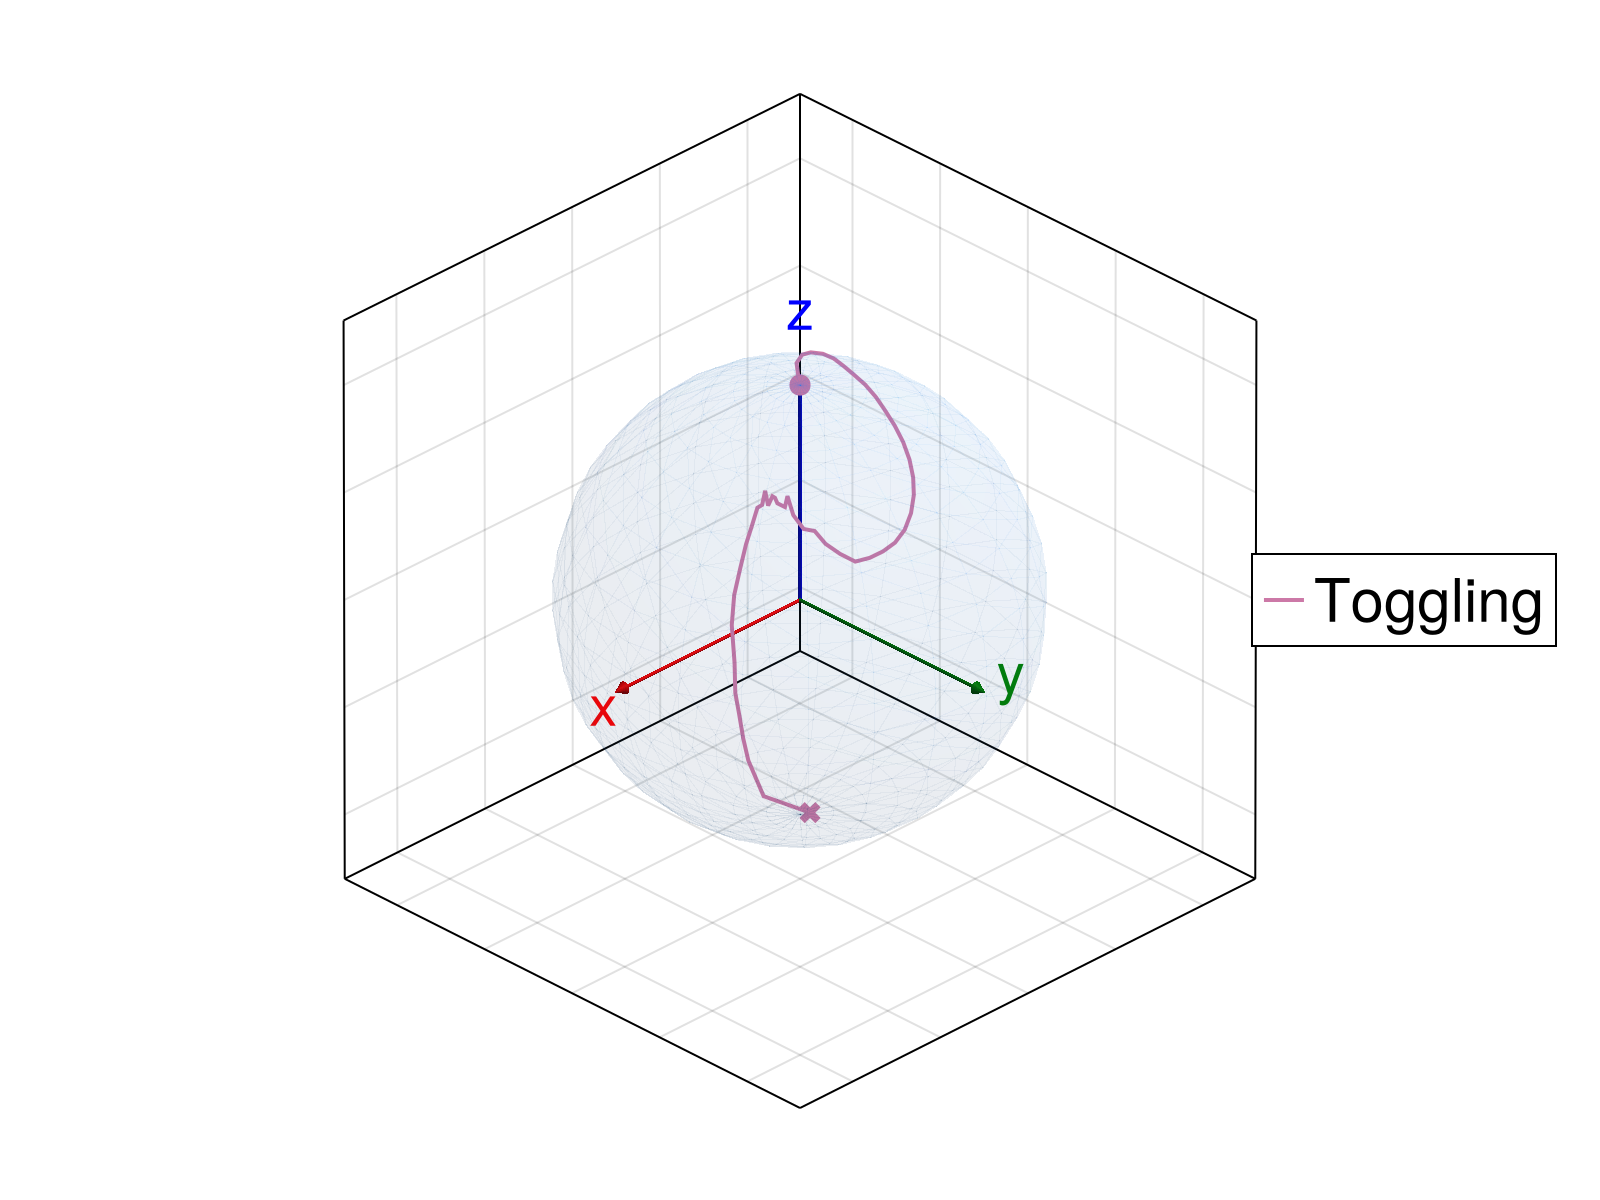

In [139]:
using CairoMakie
using GeometryBasics

default_traj = def.trajectory
tog_traj     = add_prob.trajectory
var_traj     = varadd_prob.trajectory


colors = [ Makie.wong_colors()[4],]
ket_0 = [1.0,0.0]
traj_vec = [tog_traj]
labels = ["Toggling",]
rho_0 = ket_0 * ket_0'

f  = CairoMakie.Figure(resolution = (800, 600))
ax = CairoMakie.Axis3(f[1, 1];
    aspect = :equal
)

palette = to_colormap(:tab10)
styles  = (:solid, :dash, :dot, :dashdot)

origins = [Point3f(0,0,0), Point3f(0,0,0), Point3f(0,0,0)]
dirs    = [Vec3f(1.0,0,0), Vec3f(0,1.0,0), Vec3f(0,0,1.0)]

CairoMakie.arrows!(ax, origins, dirs;
    color = [:red, :green, :blue],
    arrowsize = 0.05,
    linewidth = 0.01
)

CairoMakie.text!(ax, "x", position = Point3f(1.2, 0, 0), align = (:left, :center),  color = :red,   fontsize = 28)
CairoMakie.text!(ax, "y", position = Point3f(0, 1.2, 0), align = (:center, :bottom), color = :green, fontsize = 28)
CairoMakie.text!(ax, "z", position = Point3f(0, 0, 1.2), align = (:center, :bottom), color = :blue,  fontsize = 28)

for (i, traj) in enumerate(traj_vec)
    expect_val_x = [real(tr(PAULIS.X * iso_vec_to_operator(traj.Ũ⃗[:, t]) * rho_0 * iso_vec_to_operator(traj.Ũ⃗[:, t])')) for t in 1:traj.T]
    expect_val_y = [real(tr(PAULIS.Y * iso_vec_to_operator(traj.Ũ⃗[:, t]) * rho_0 * iso_vec_to_operator(traj.Ũ⃗[:, t])')) for t in 1:traj.T]
    expect_val_z = [real(tr(PAULIS.Z * iso_vec_to_operator(traj.Ũ⃗[:, t]) * rho_0 * iso_vec_to_operator(traj.Ũ⃗[:, t])')) for t in 1:traj.T]

    CairoMakie.lines!(ax, real.(expect_val_x), real.(expect_val_y), real.(expect_val_z);
        color = colors[i],
        label = labels[i],
        #linestyle = styles[i],
        linewidth = 2.0
    )

    CairoMakie.scatter!(ax, [real(expect_val_x[end])], [real(expect_val_y[end])], [real(expect_val_z[end])];
        color = colors[i], markersize = 15, marker = :xcross)
    CairoMakie.scatter!(ax, [real(expect_val_x[1])], [real(expect_val_y[1])], [real(expect_val_z[1])];
        color = colors[i], markersize = 15)

end
CairoMakie.mesh!(ax, Sphere(Point3f(0,0,0), 1f0);
    color = (0.2, 0.6, 1.0, 0.05),
    transparency = true,
    shading = true
)

CairoMakie.xlims!(ax, -1.3, 1.3)
CairoMakie.ylims!(ax, -1.3, 1.3)
CairoMakie.zlims!(ax, -1.3, 1.3)

ax.azimuth[]   =  π/4
ax.elevation[] =  π/6

#CairoMakie.axislegend(ax; position = :rt, fontsize=40)
CairoMakie.hidexdecorations!(ax, grid = false)
CairoMakie.hideydecorations!(ax, grid = false)
CairoMakie.hidezdecorations!(ax, grid = false)

CairoMakie.axislegend(ax; position = :rc, labelsize = 30)
#save("modq_plot.png", f)
f  
     

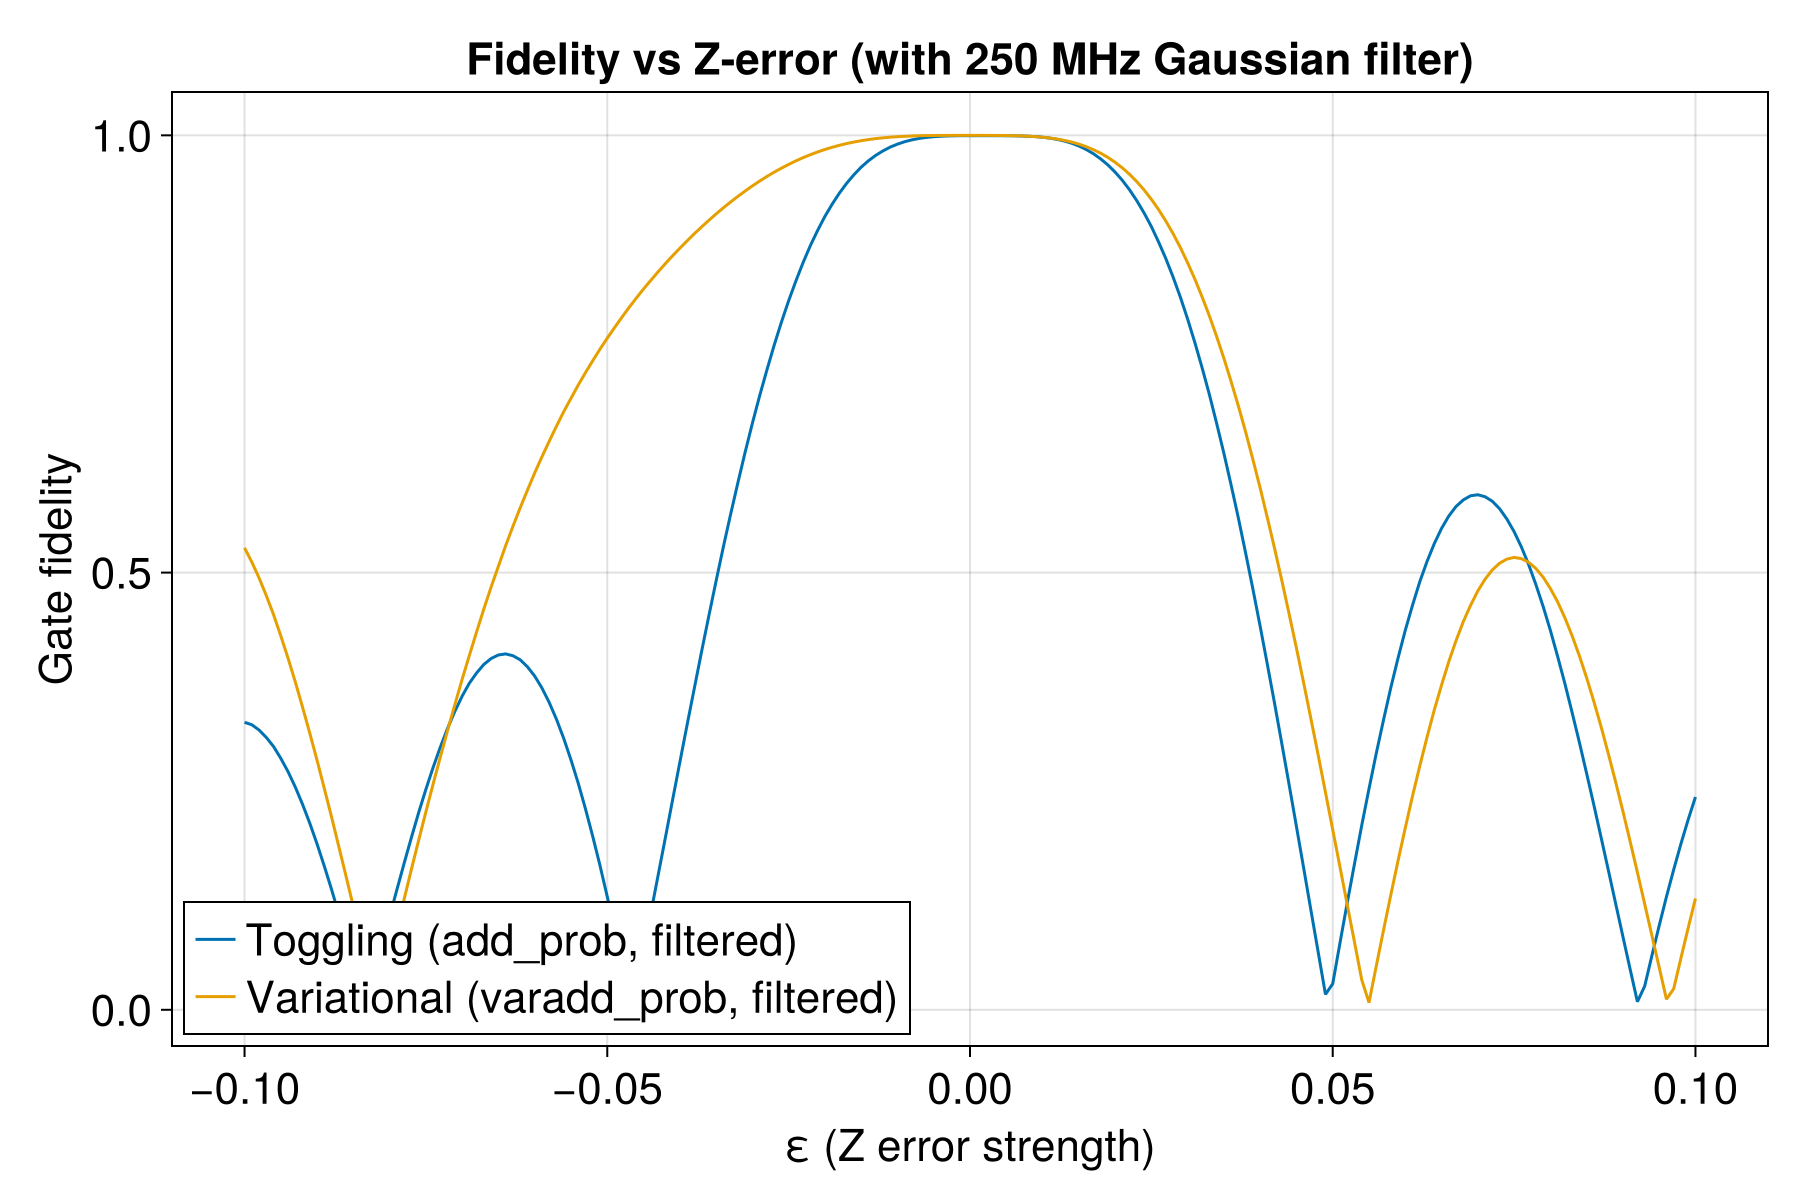

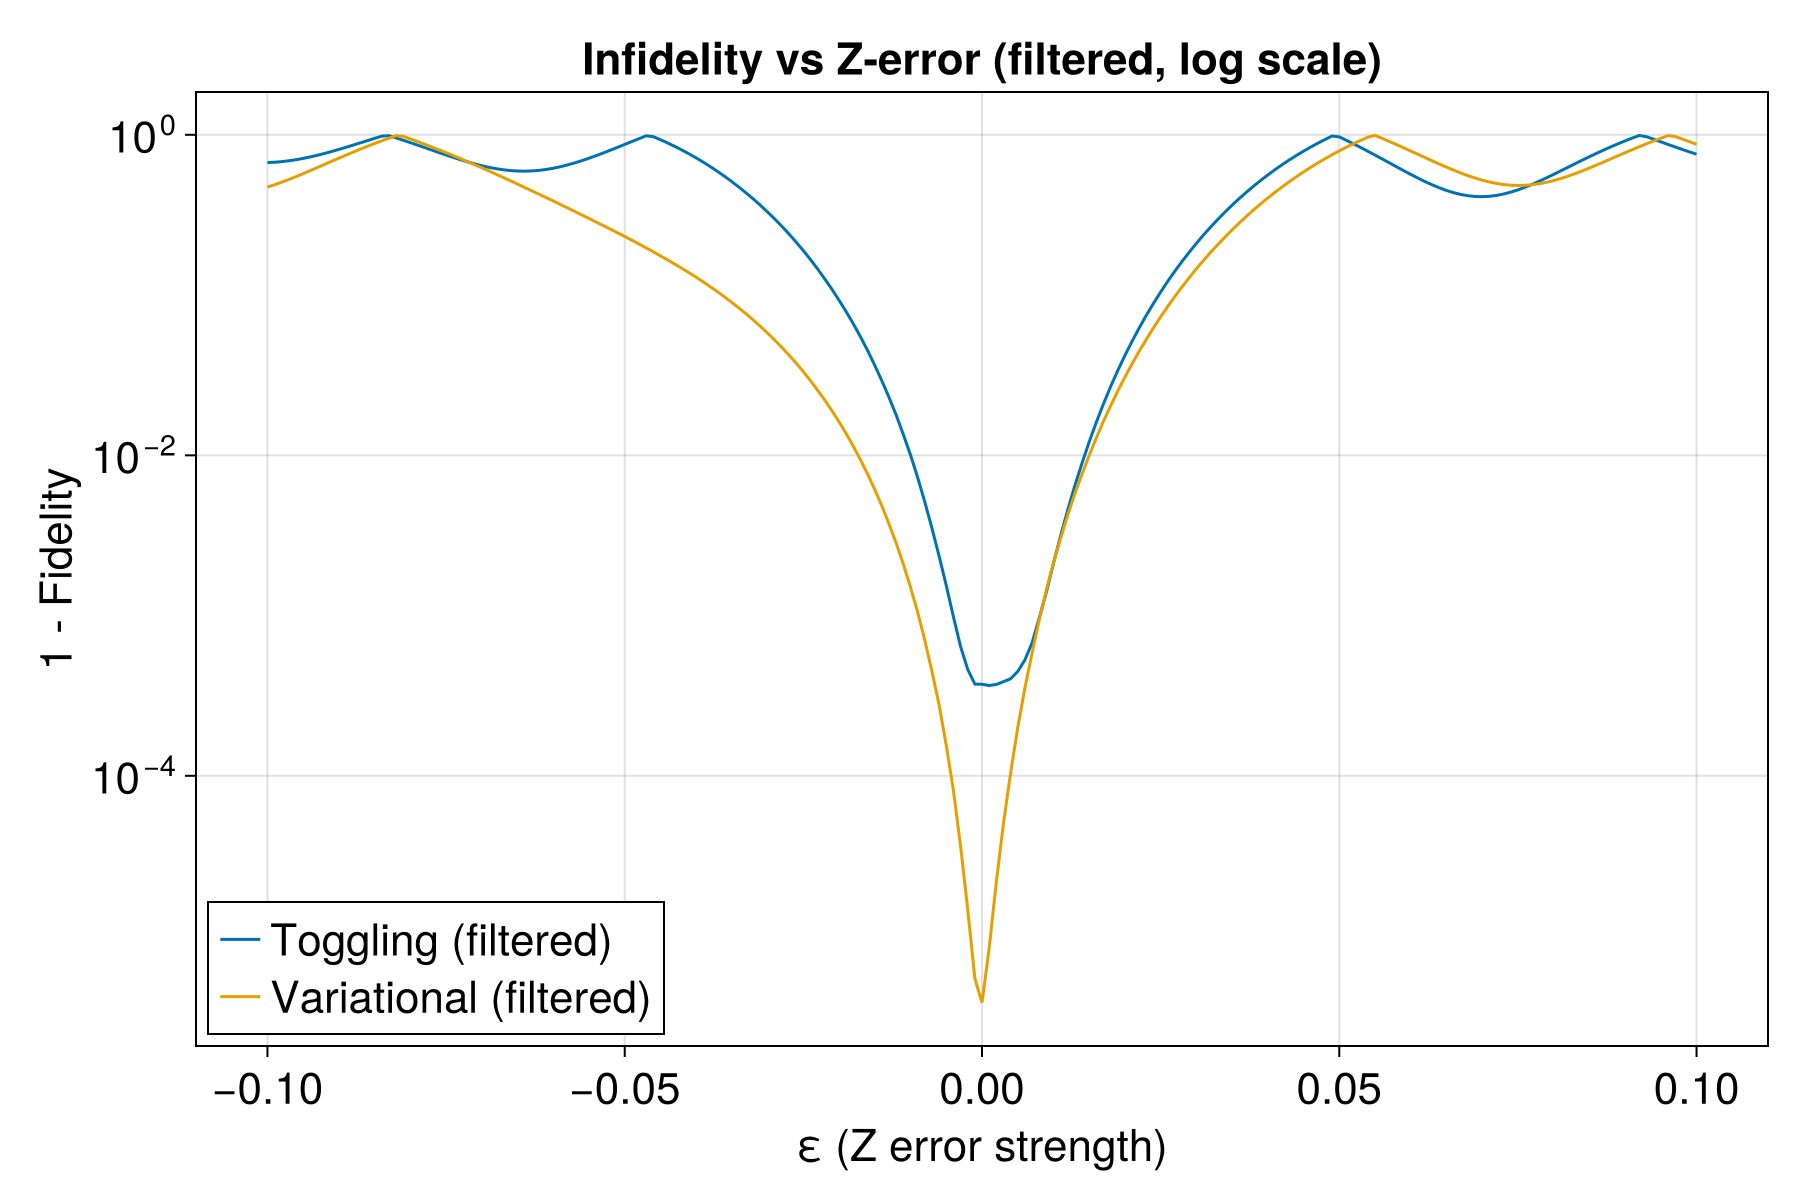

CairoMakie.Screen{IMAGE}


In [140]:
using QuantumToolbox
using FFTW
using CairoMakie

const QT = QuantumToolbox  # avoid name shadowing

# ----------------------------------------------------------
# 0. Filter helpers: ZOH upsample + 250 MHz Gaussian
# ----------------------------------------------------------

"""
Return FFT frequency axis (Hz) for length N and timestep dt_s (seconds),
matching the ordering of fft(u).
"""
function flt_fftfreq(N::Int, dt_s::Float64)
    df = 1.0 / (N * dt_s)
    freqs = [k <= N ÷ 2 ? k : k - N for k in 0:N-1]
    return df .* freqs
end

"""
Gaussian amplitude response with given -3 dB bandwidth B3dB_Hz (Hz).

|G(f)| = exp( - f^2 / (2 σ_f^2) ), with σ_f = B3dB / sqrt(log(2)).
This gives -3 dB in *power* at f = B3dB_Hz.
"""
function flt_gaussian_response(freqs::AbstractVector{<:Real}, B3dB_Hz::Float64)
    σf = B3dB_Hz / sqrt(log(2.0))
    return @. exp(-0.5 * (freqs^2) / σf^2)
end

"""
Apply a 250 MHz Gaussian filter to coarse controls u_x, u_y.

Inputs:
  u_x_coarse, u_y_coarse  -- controls on coarse grid (GHz)
  dt_ns                   -- coarse timestep in ns (e.g. 2.0)
  M                       -- upsampling factor (e.g. 20)
  B3dB_Hz                 -- -3 dB Gaussian bandwidth in Hz (e.g. 250e6)

Returns:
  u_x_filt, u_y_filt      -- filtered controls on fine grid (GHz)
  dt_fine_ns              -- fine timestep in ns
"""
function apply_gaussian_filter_to_controls(u_x_coarse::AbstractVector,
                                           u_y_coarse::AbstractVector;
                                           dt_ns::Real,
                                           M::Int = 20,
                                           B3dB_Hz::Real = 250e6)

    @assert length(u_x_coarse) == length(u_y_coarse)
    N_coarse = length(u_x_coarse)

    dt_coarse_ns = Float64(dt_ns)
    dt_coarse_s  = dt_coarse_ns * 1e-9      # seconds
    dt_fine_s    = dt_coarse_s / M
    dt_fine_ns   = dt_coarse_ns / M         # for the Schrödinger solver

    # ZOH upsampling
    u_x_zoh = repeat(u_x_coarse, inner = (M,))
    u_y_zoh = repeat(u_y_coarse, inner = (M,))
    u_zoh   = u_x_zoh .+ 1im .* u_y_zoh

    N_fine = length(u_x_zoh)

    # Frequency axis + Gaussian filter
    freqs = flt_fftfreq(N_fine, dt_fine_s)
    G     = flt_gaussian_response(freqs, B3dB_Hz)

    # Apply filter in frequency domain
    U      = fft(u_zoh)
    U_filt = G .* U
    u_out  = ifft(U_filt)

    u_x_filt = real.(u_out)
    u_y_filt = imag.(u_out)

    return u_x_filt, u_y_filt, dt_fine_ns
end

# ----------------------------------------------------------
# 1. Simulation helper: fidelity for one set of controls & εZ
# ----------------------------------------------------------

"""
Simulate the unitary for controls u_x(t), u_y(t) with timestep dt_ns (ns) and
constant Z-error ε, using

    H(t) = u_x(t) σ_x + u_y(t) σ_y + ε σ_z,

and return the single-qubit gate fidelity to target Hadamard H:

    F = |Tr(H† U(T))| / 2
"""
function simulate_fidelity_for_controls(u_x::AbstractVector,
                                        u_y::AbstractVector,
                                        dt_ns::Real,
                                        ε::Real,
                                        had_q::QT.QuantumObject)

    N = length(u_x)
    @assert length(u_y) == N "u_x and u_y must have same length"

    dt_f = Float64(dt_ns)         # time step in "ns units"
    T    = (N - 1) * dt_f
    tlist = collect(0.0:dt_f:T)

    sx = QT.sigmax()
    sy = QT.sigmay()
    sz = QT.sigmaz()

    # ZOH coefficients for controls
    function ux_coef(p, t)
        t_clamped = clamp(t, 0.0, T)
        idx       = Int(floor(t_clamped / dt_f)) + 1
        return u_x[idx]
    end

    function uy_coef(p, t)
        t_clamped = clamp(t, 0.0, T)
        idx       = Int(floor(t_clamped / dt_f)) + 1
        return u_y[idx]
    end

    # Constant Z-error coefficient
    function uz_coef(p, t)
        return ε
    end

    # H(t) = u_x(t) σ_x + u_y(t) σ_y + ε σ_z
    # (If your actual convention has a 2π factor, multiply sx,sy,sz by 2π here.)
    H_t = QT.QobjEvo((
        (sx, ux_coef),
        (sy, uy_coef),
        (sz, uz_coef),
    ))

    ψ0 = QT.basis(2, 0)
    ψ1 = QT.basis(2, 1)

    sol0 = QT.sesolve(H_t, ψ0, tlist; progress_bar = Val(false))
    sol1 = QT.sesolve(H_t, ψ1, tlist; progress_bar = Val(false))

    ψT_0 = sol0.states[end]
    ψT_1 = sol1.states[end]

    v0 = ψT_0.data
    v1 = ψT_1.data
    U_T = hcat(v0, v1)               # 2×2 matrix

    U_q = QT.QuantumObject(U_T)
    F   = abs(tr(had_q' * U_q)) / 2  # single-qubit gate fidelity
    return F
end

# ----------------------------------------------------------
# 2. Extract coarse controls from both problems
# ----------------------------------------------------------

# Toggling objective (add_prob)
u_x_add_coarse = add_prob.trajectory.a[1, :]
u_y_add_coarse = add_prob.trajectory.a[2, :]
Δt_add_ns      = Float64(add_prob.trajectory.Δt[1])   # e.g. 2.0

# Adjoint/variational objective (varadd_prob)
u_x_var_coarse = varadd_prob.trajectory.a[1, :]
u_y_var_coarse = varadd_prob.trajectory.a[2, :]
Δt_var_ns      = Float64(varadd_prob.trajectory.Δt[1])  # e.g. 2.0

# ----------------------------------------------------------
# 3. Apply Gaussian filter (250 MHz) to both sets of controls
# ----------------------------------------------------------
M_upsample = 20
B3dB = 250e6

u_x_add_filt, u_y_add_filt, Δt_add_fine_ns =
    apply_gaussian_filter_to_controls(u_x_add_coarse, u_y_add_coarse;
                                      dt_ns = Δt_add_ns,
                                      M = M_upsample,
                                      B3dB_Hz = B3dB)

u_x_var_filt, u_y_var_filt, Δt_var_fine_ns =
    apply_gaussian_filter_to_controls(u_x_var_coarse, u_y_var_coarse;
                                      dt_ns = Δt_var_ns,
                                      M = M_upsample,
                                      B3dB_Hz = B3dB)

# ----------------------------------------------------------
# 4. Define target gate and ε-range, compute fidelities
# ----------------------------------------------------------
had_q = QT.QuantumObject(GATES.X)  # Hadamard from PiccoloQuantumObjects

εs = collect(-0.1:0.001:0.1)       # Z-error strengths (same units as your u's)

F_add = similar(εs, Float64)
F_var = similar(εs, Float64)

for (i, ε) in enumerate(εs)
    F_add[i] = simulate_fidelity_for_controls(u_x_add_filt, u_y_add_filt,
                                              Δt_add_fine_ns, ε, had_q)
    F_var[i] = simulate_fidelity_for_controls(u_x_var_filt, u_y_var_filt,
                                              Δt_var_fine_ns, ε, had_q)
    println("ε = $(round(ε, digits=4)): F_add = $(F_add[i]), F_var = $(F_var[i])")
end

# ----------------------------------------------------------
# 5. Plot fidelity vs ε for both methods
# ----------------------------------------------------------
CairoMakie.activate!()

fig1 = Figure(resolution = (900, 600), fontsize = 22)
ax1  = Axis(fig1[1, 1],
    xlabel = "ε (Z error strength)",
    ylabel = "Gate fidelity",
    title  = "Fidelity vs Z-error (with 250 MHz Gaussian filter)"
)

lines!(ax1, εs, F_add, label = "Toggling (add_prob, filtered)")
lines!(ax1, εs, F_var, label = "Variational (varadd_prob, filtered)")

axislegend(ax1, position = :lb)
display(fig1)

# Optional: infidelity in log scale
fig2 = Figure(resolution = (900, 600), fontsize = 22)
ax2  = Axis(fig2[1, 1],
    xlabel = "ε (Z error strength)",
    ylabel = "1 - Fidelity",
    yscale = log10,
    title  = "Infidelity vs Z-error (filtered, log scale)"
)

lines!(ax2, εs, 1 .- F_add, label = "Toggling (filtered)")
lines!(ax2, εs, 1 .- F_var, label = "Variational (filtered)")

axislegend(ax2, position = :lb)
display(fig2)

# save("fidelity_vs_epsilon_filtered.png", fig1)
# save("infidelity_vs_epsilon_filtered_log.png", fig2)